# Assessing Crime Types as Indicators of Urban Crime Risk in London:Theft, Burglary, and Violence Across LSOAs

## Preparation

- https://github.com/ChloeJing0616/DSSS/tree/main

- Number of words: 1526（narrative only）

- Runtime: 0.5 hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
   * xgboost: Gradient boosting framework used for XGBoost regression models
   * shap: Model interpretability library used for SHAP TreeExplainer and beeswarm plots
   * osmnx: OpenStreetMap network analysis library used to extract road network metrics (betweenness centrality, intersection density)

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [EDA](#EDA)

1. [Methodology](#Methodology)

1. [Results](#Results)

1. [Discussion](#Discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## 1.Introduction

[[ go back to the top ]](#Table-of-contents)

Urban crime is a long-term challenge with clear spatial patterns. In London, despite the Mayor’s Police and Crime Plan 2025–2029, some offences, particularly theft, continue to rise, and around 48% of residents reported concern about crime in their local area in 2024 (MOPAC, 2025). Identifying which crime types best represent urban crime risk, and how they relate to urban structure, is therefore important for targeted crime prevention.

This study focuses on three crime types: theft, burglary, and violence. These are selected for two reasons. First, they form a large share of neighbourhood crime in London and are policy priorities (Mayor of London, 2025). Second, unlike fraud or cybercrime, they are strongly spatial and consistently recorded at LSOA level, enabling fine-scale analysis. They also reflect different urban mechanisms. Theft is opportunity-driven, arising from the convergence of offenders and targets in active spaces, consistent with Routine Activity Theory (Cohen & Felson, 1979). Violence is linked to deprivation and social disorganisation, and clusters in disadvantaged areas (Sampson et al., 1997). Burglary relates more to residential vulnerability and limited guardianship, and may be less explained by broader urban structure due to household-level factors (Bernasco & Nieuwbeerta, 2005). In this study, the most representative crime type is defined as the one whose spatial pattern is best explained by urban structural features, measured by higher predictive R² and more stable SHAP patterns.

Explanatory variables are selected from urban criminology theory: IMD for deprivation, population and workplace density for exposure, POI density for urban activity, and road network measures (betweenness centrality and intersection density) for movement patterns (Brantingham & Brantingham, 1993). Four models are evaluated using five-fold cross-validation, with SHAP used for interpretation (Lundberg & Lee, 2017). This allows comparison of how strongly each crime type is shaped by urban structure.

## 2.Research questions

[[ go back to the top ]](#Table-of-contents)

**Central Research Question:** Which crime type — theft, burglary, or violence — best represents urban crime in London LSOAs?

**Sub-questions:**

- **Urban mechanisms:** Are different crime types driven by different urban structural features, and to what extent?

- **Model performance:** Do tree-based models outperform a linear baseline in predicting crime rates, and does the performance advantage vary by crime type?

- **Feature interpretability:** Which urban structural features most strongly drive predictions for each crime type according to SHAP analysis?

## 3.Data

[[ go back to the top ]](#Table-of-contents)

*[Note: a table that describes the selected variables for analysis and modelling is required - see the example below.]*

### 3.1 Data Sources

The data are primarily drawn from six datasets, covering crime records, socioeconomic deprivation, population exposure, urban activity, road network structure, and spatial boundaries.

| Dataset | Source | Spatial Coverage | Temporal Coverage |
|---|---|---|---|
| Crime Records (Theft, Burglary, Violence) | London Datastore (data.london.gov.uk) | Greater London (LSOA) | 2022–2024 |
| Index of Multiple Deprivation (IMD 2019) | UK Ministry of Housing, Communities & Local Government (MHCLG), IMD 2019 | England (LSOA) | 2019 |
| Population & Workplace Density | Population density: ONS Census 2021; Workplace density: ONS Workplace Population (WP dataset) | England & Wales (LSOA) | 2021 |
| Points of Interest — Food, Shop, Nightlife | OpenStreetMap (OSM) | Greater London | Accessed 2024 |
| Road Network — Betweenness, Intersections | OpenStreetMap (extracted via OSMnx), with network metrics (betweenness centrality, intersection density) computed by the author | Greater London | Accessed 2024 |
| LSOA Boundaries | ONS Open Geography Portal | Greater London | 2011 (harmonised to 2021 codes via ONS lookup table) |

*Note: Temporal mismatches across datasets reflect the availability of official sources. Crime rates are averaged across 2022–2024 to reduce year-to-year volatility.*

### 3.2 Data Preparation

Data was prepared using the following methods:

| Category | Source / Method | Description & Preprocessing |
|---|---|---|
| Target Variables (Y) | London Datastore (data.london.gov.uk) | Three crime rates calculated per LSOA: theft rate, burglary rate, and violence rate (annual average crime count 2022–2024 / population × 1,000). Annual rates were computed separately for each year and averaged across three years to reduce year-to-year volatility. Right-skewed distributions normalised using log1p transformation prior to modelling. |
| Socioeconomic Deprivation | Index of Multiple Deprivation (IMD) 2019, UK Ministry of Housing, Communities & Local Government (MHCLG) | Area-level deprivation score at LSOA level. Standardised directly using StandardScaler without prior transformation, as the distribution was approximately uniform. |
| Population Exposure | ONS Census 2021 | Population density and workplace density (persons per km² and workplaces per km²). Workplace density log-transformed to normalise right-skewed distribution. |
| Urban Activity (POI) | OpenStreetMap (OSM, accessed 2024) | Point counts for food establishments, retail shops, and nightlife venues aggregated to LSOA level and converted to density (POIs per km²). Log1p transformation applied to handle zero-inflated distributions (up to 65% zero values in nightlife POI). POIs represent a snapshot at the time of extraction from OSM, a continuously updated crowd-sourced database. |
| Road Network | OpenStreetMap via OSMnx Python library | A rank-based transformation was applied to betweenness centrality to reduce the influence of extreme values. Intersection density retained without transformation as distribution approached normality. |
| Feature Engineering | Derived interaction terms | Three interaction terms were constructed from standardised variables:IMD × Night POI (deprivation under nightlife exposure), Workplace × Food POI (daytime activity intensity), and Betweenness × Night POI (network exposure during night activity). |

### 3.3 Variables Selected

The final analytical feature set comprised 11 predictor variables across 4 groups, with 3 target variables.

### Target Variables (Y)

| Variable | Type | Definition |
|---|---|---|
| `theft_rate` | Continuous | Theft offences per 1,000 residents per LSOA, averaged 2022–2024. Log1p-transformed prior to modelling. |
| `burglary_rate` | Continuous | Burglary offences per 1,000 residents per LSOA, averaged 2022–2024. Log1p-transformed prior to modelling. |
| `violence_rate` | Continuous | Violence against the person offences per 1,000 residents per LSOA, averaged 2022–2024. Log1p-transformed prior to modelling. |

### Predictor Variables (X)

**Socioeconomic Deprivation (1)**

| Variable | Type | Definition |
|---|---|---|
| `imd_score` | Continuous | Index of Multiple Deprivation 2019 score at LSOA level. Higher values indicate greater deprivation. |

**Population Exposure (2)**

| Variable | Type | Definition |
|---|---|---|
| `pop_density` | Continuous | Residential population per km². Reflects baseline human presence and potential victim exposure. |
| `workplace_density` | Continuous | Workplaces per km². Captures daytime population exposure beyond residential population. Log-transformed prior to modelling. |

**Urban Activity — POI Density (3)**

| Variable | Type | Definition |
|---|---|---|
| `food_poi_density` | Continuous | Food and beverage establishments per km². Proxy for daytime pedestrian activity and footfall. |
| `shop_poi_density` | Continuous | Retail shops per km². Proxy for commercial activity and concentration of potential theft targets. |
| `night_poi_density` | Continuous | Nightlife venues per km². Proxy for evening and late-night population exposure. Log1p-transformed; 65% zero values across LSOAs. |

**Road Network Structure (2)**

| Variable | Type | Definition |
|---|---|---|
| `betweenness_centrality` | Continuous | Proportion of shortest paths passing through each node, aggregated to LSOA level. Reflects network throughput and potential offender movement corridors. Rank-transformed prior to modelling. |
| `intersection_density` | Continuous | Number of road intersections per km². Reflects local street connectivity and pedestrian permeability. |

**Interaction Terms (3)**

| Variable | Type | Definition |
|---|---|---|
| `imd_x_night` | Continuous | IMD Score × Night POI Density. Captures the compounding effect of deprivation and nightlife exposure on crime risk. |
| `workplace_x_food` | Continuous | Workplace Density × Food POI Density. Captures combined daytime activity intensity in commercial areas. |
| `btwn_x_night` | Continuous | Betweenness Centrality × Night POI Density. Captures the interaction between network hub locations and nighttime activity exposure. |

### 3.4 Data Processing

All preprocessing steps are implemented sequentially below. Datasets are merged by LSOA code, with log1p, rank transformations, and standardisation applied for modelling. 

Due to file size constraints, raw datasets were pre-processed locally and are not included. The final analytical dataset (final_dataset.csv) contains all processed LSOA-level variables, and all transformations are documented in this notebook to ensure reproducibility.

In [156]:
# All preprocessing steps have been completed locally.
# Raw datasets are not included in this repository due to file size constraints.
# All features used for analysis and modelling are loaded directly from final_dataset.csv,
# which contains the processed LSOA-level dataset ready for use.
# To reproduce the dataset, run the notebook from start to finish

# Data loaded:
# lsoa_crime_rates.csv   – LSOA-level crime rates (annual average 2022–2024)
# population.csv         – LSOA-level population data (ONS Census 2021)
# final_dataset.csv      – processed LSOA-level dataset including:
#                            - urban features:
#                                * population exposure (pop_density, workplace_density)
#                                * urban activity (food_poi_density, shop_poi_density, night_poi_density)
#                                * road network (betweenness, intersection_density)
# imd_lsoa.csv           – LSOA-level Index of Multiple Deprivation score (IMD 2019)

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [121]:
# Base URL for accessing raw data
base_url = "https://raw.githubusercontent.com/ChloeJing0616/DSSS/main/submission/"

In [122]:
# Load crime rate data
crime_rate = pd.read_csv(base_url + "lsoa_crime_rates.csv")
# Load population data
population = pd.read_csv(base_url + "population.csv")
# Load urban features dataset
final_dataset = pd.read_csv(base_url + "final_dataset.csv")
# Load IMD score directly
imd = pd.read_csv(base_url + "imd_lsoa.csv")

In [157]:
print(f"crime_rate:    {crime_rate.shape}    columns: {crime_rate.columns.tolist()}")
print(f"population:    {population.shape}    columns: {population.columns.tolist()}")
print(f"final_dataset: {final_dataset.shape} columns: {final_dataset.columns.tolist()}")
print(f"imd:           {imd.shape}           columns: {imd.columns.tolist()}")

print("\n── crime_rate sample ──")
display(crime_rate.head(3))
print("\n── population sample ──")
display(population.head(3))
print("\n── final_dataset sample ──")
display(final_dataset.head(3))
print("\n── imd sample ──")
display(imd.head(3))
print("\n── imd sample ──")

print("\nData loading complete.")

crime_rate:    (4988, 8)    columns: ['LSOA_code', 'population', 'burglary_annual_avg', 'theft_annual_avg', 'violence_annual_avg', 'burglary_rate', 'theft_rate', 'violence_rate']
population:    (35672, 6)    columns: ['date', 'geography', 'geography code', 'Residence type: Total; measures: Value', 'Residence type: Lives in a household; measures: Value', 'Residence type: Lives in a communal establishment; measures: Value']
final_dataset: (4659, 9) columns: ['LSOA_code', 'population', 'pop_density', 'workplace_density', 'food_poi_density', 'shop_poi_density', 'night_poi_density', 'betweenness', 'intersection_density']
imd:           (4835, 2)           columns: ['LSOA_code', 'imd_score']

── crime_rate sample ──


,LSOA_code,population,burglary_annual_avg,theft_annual_avg,violence_annual_avg,burglary_rate,theft_rate,violence_rate
0,E01000006,1845,2.6667,37.6667,33.3333,1.4453,20.4155,18.0668
1,E01000007,2908,18.0000,196.3333,166.3333,6.1898,67.5149,57.1985
2,E01000008,1795,10.3333,66.3333,62.0000,5.7567,36.9545,34.5404



── population sample ──


,date,geography,geography code,Residence type: Total; measures: Value,Residence type: Lives in a household; measures: Value,Residence type: Lives in a communal establishment; measures: Value
0,2021,Hartlepool 001A,E01011954,2284,2284,0
1,2021,Hartlepool 001B,E01011969,1344,1344,0
2,2021,Hartlepool 001C,E01011970,1070,1070,0



── final_dataset sample ──


,LSOA_code,population,pop_density,workplace_density,food_poi_density,shop_poi_density,night_poi_density,betweenness,intersection_density
0,E01000001,1475.0,11063.542564,24422.301415,105.009896,67.506361,30.002827,0.005040,172.516257
1,E01000002,1384.0,6118.715289,31964.097935,88.420741,22.105185,22.105185,0.001856,114.946963
2,E01000003,1613.0,28148.629970,15077.753437,34.902207,122.157725,17.451104,0.000692,87.255518



── imd sample ──


,LSOA_code,imd_score
0,E01000001,3645
1,E01000002,2465
2,E01000003,17929



── imd sample ──

Data loading complete.


In [125]:
# Data Processing
# Transformations are applied based on distributional diagnostics from EDA.
# log1p is used for right-skewed and zero-inflated variables;
# rank transformation is used where log1p showed negligible improvement.
# StandardScaler is applied for Ridge regression only (linear baseline).
# Tree-based models (Decision Tree, Random Forest, XGBoost) are
# invariant to feature scaling and do not require standardisation.

import joblib
from sklearn.preprocessing import StandardScaler

# Step 0: Merge all datasets into one dataframe
df = final_dataset.merge(
    crime_rate[['LSOA_code', 'theft_rate', 'burglary_rate', 'violence_rate']],
    on='LSOA_code', how='inner'
).merge(
    imd[['LSOA_code', 'imd_score']],
    on='LSOA_code', how='inner'
)
print(f"Input shape: {df.shape}")

# Define column roles
ID_COL = 'LSOA_code'

# log1p transformation (right-skewed or zero-inflated variables)
LOG1P_COLS = [
    'workplace_density',   # severely right-skewed
    'pop_density',         # right-skewed
    'food_poi_density',    # 44.6% zero values
    'shop_poi_density',    # 33.3% zero values
    'night_poi_density',   # 65.1% zero values
    'theft_rate',          # extremely right-skewed
    'burglary_rate',       # right-skewed
    'violence_rate',       # extremely right-skewed
]

# Rank transformation (log1p showed limited improvement)
RANK_COLS = [
    'betweenness',         # skewness: 2.41 → 2.34 after log1p, almost no improvement
]

# Direct standardisation (approximately normal or uniform distribution)
DIRECT_COLS = [
    'intersection_density',  # approximately normal
    'imd_score',             # approximately uniform
    # 'population' excluded: crime rate = count/population × 1,000
    # including population as X would introduce a denominator effect
]

# Step 1: log1p transformation
df_proc = df[[ID_COL]].copy()
print("\n── Step 1: log1p transform ──")
for col in LOG1P_COLS:
    new_col = f'{col}_log'
    df_proc[new_col] = np.log1p(df[col])
    print(f"  {col:25s} → {new_col}  "
          f"(skew: {df[col].skew():.2f} → {df_proc[new_col].skew():.2f})")

# Step 1b: rank transformation
print("\n── Step 1b: rank transform ──")
for col in RANK_COLS:
    new_col = f'{col}_rank'
    df_proc[new_col] = df[col].rank(pct=True)
    print(f"  {col:25s} → {new_col}  "
          f"(skew: {df[col].skew():.2f} → {df_proc[new_col].skew():.2f})")

# Directly copy columns without transformation
for col in DIRECT_COLS:
    df_proc[col] = df[col]

# Step 2: StandardScaler
print("\n── Step 2: StandardScaler ──")
log_cols   = [f'{c}_log'  for c in LOG1P_COLS]
rank_cols  = [f'{c}_rank' for c in RANK_COLS]
scale_cols = log_cols + rank_cols + DIRECT_COLS

scaler = StandardScaler()
scaled = scaler.fit_transform(df_proc[scale_cols])
df_scaled = pd.DataFrame(scaled, columns=scale_cols, index=df_proc.index)

# Final dataframe: ID + all processed features
df_final = pd.concat([df_proc[[ID_COL]], df_scaled], axis=1)
print(f"  Scaled {len(scale_cols)} columns")
print(f"  Output shape: {df_final.shape}")
print(f"  Columns: {df_final.columns.tolist()}")

# Step 3: Validation — mean ≈ 0, std ≈ 1
print("\n── Step 3: Validation (mean / std after scaling) ──")
stats = df_final[scale_cols].agg(['mean', 'std']).round(4)
print(stats.to_string())

# df_final is retained in memory for subsequent modelling cells

Input shape: (4653, 13)

── Step 1: log1p transform ──
  workplace_density         → workplace_density_log  (skew: 5.05 → -0.35)
  pop_density               → pop_density_log  (skew: 1.20 → -1.16)
  food_poi_density          → food_poi_density_log  (skew: 5.78 → 0.54)
  shop_poi_density          → shop_poi_density_log  (skew: 4.14 → 0.20)
  night_poi_density         → night_poi_density_log  (skew: 7.05 → 1.23)
  theft_rate                → theft_rate_log  (skew: 24.46 → 1.36)
  burglary_rate             → burglary_rate_log  (skew: 4.57 → 0.48)
  violence_rate             → violence_rate_log  (skew: 10.80 → 0.26)

── Step 1b: rank transform ──
  betweenness               → betweenness_rank  (skew: 2.40 → 0.00)

── Step 2: StandardScaler ──
  Scaled 11 columns
  Output shape: (4653, 12)
  Columns: ['LSOA_code', 'workplace_density_log', 'pop_density_log', 'food_poi_density_log', 'shop_poi_density_log', 'night_poi_density_log', 'theft_rate_log', 'burglary_rate_log', 'violence_rate_log', 'b

## 4.Exploratory Data Analysis（EDA）

[[ go back to the top ]]

### 4.1 distribution

**1.Figures 1.1–1.3** show that all three crime rate variables are heavily right-skewed 
(theft: 25.46, violence: 9.60, burglary: 5.42), indicating that crime is 
spatially concentrated in a small number of LSOAs rather than evenly distributed 
across London. Log1p transformation was applied to reduce skewness before modelling.

**2.Figures 2.1–2.8** show that urban activity variables are strongly right-skewed and contain a large number of zero values. Five variables required log1p transformation: Nightlife POI Density (6.92), Food POI Density (5.71), Workplace Density (4.97), Shop POI Density (4.13), and Population Density (1.20). Betweenness Centrality (2.41) required rank transformation, while Intersection Density and IMD Score required none. The skewed distributions and the high proportion of zero values in Nightlife POI (65%) suggest non-linear relationships between urban features and crime rates, motivating the use of tree-based models.

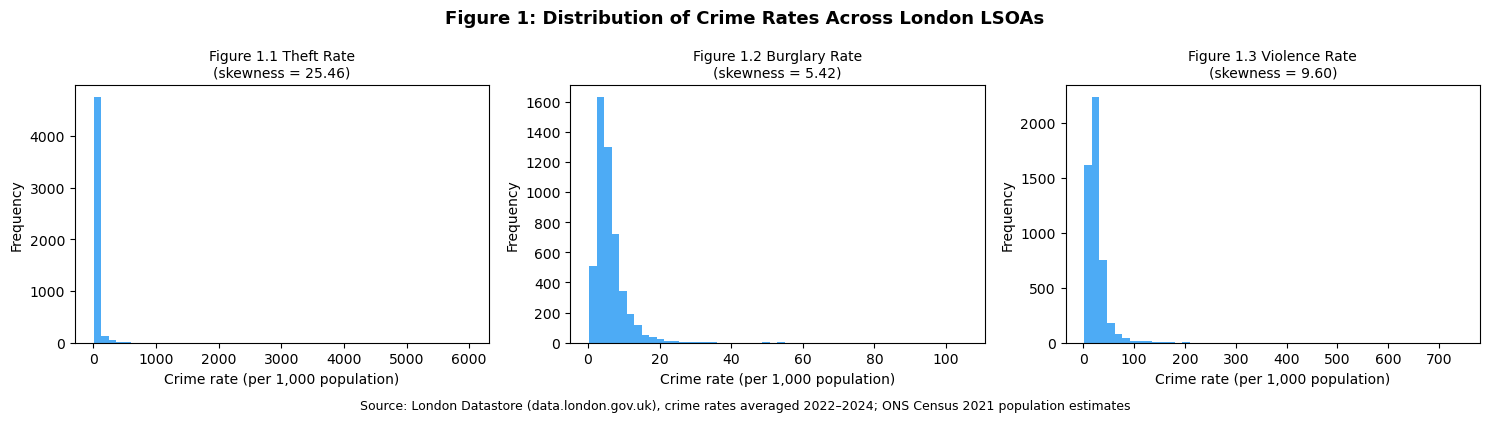


── Figure 1: Skewness Summary ──
  Theft Rate     : skewness = 25.46  → log1p transformation applied in Data Processing
  Burglary Rate  : skewness = 5.42  → log1p transformation applied in Data Processing
  Violence Rate  : skewness = 9.60  → log1p transformation applied in Data Processing


In [128]:
# Figure 1: Distribution of Crime Rates (Y variables)
# Three target variables (theft, burglary, violence) show strong right skew,
# confirming the need for log1p transformation before modelling.

import numpy as np
import matplotlib.pyplot as plt

cols_y = ['theft_rate', 'burglary_rate', 'violence_rate']
labels = ['Theft Rate', 'Burglary Rate', 'Violence Rate']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    "Figure 1: Distribution of Crime Rates Across London LSOAs",
    fontsize=13, fontweight='bold'
)

for i, (col, label) in enumerate(zip(cols_y, labels)):
    raw = crime_rate[col].dropna()
    axes[i].hist(raw, bins=50, color='#2196F3', alpha=0.8)
    axes[i].set_title(
        f"Figure 1.{i+1} {label}\n(skewness = {raw.skew():.2f})",
        fontsize=10
    )
    axes[i].set_xlabel("Crime rate (per 1,000 population)")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.figtext(
    0.5, -0.02,
    "Source: London Datastore (data.london.gov.uk), crime rates averaged 2022–2024; ONS Census 2021 population estimates",
    ha="center", fontsize=9
)
plt.show()

# Skewness values confirm right-skewed distributions across all three crime types
print("\n── Figure 1: Skewness Summary ──")
for col, label in zip(cols_y, labels):
    raw = crime_rate[col].dropna()
    print(f"  {label:15s}: skewness = {raw.skew():.2f}  → log1p transformation applied in Data Processing")

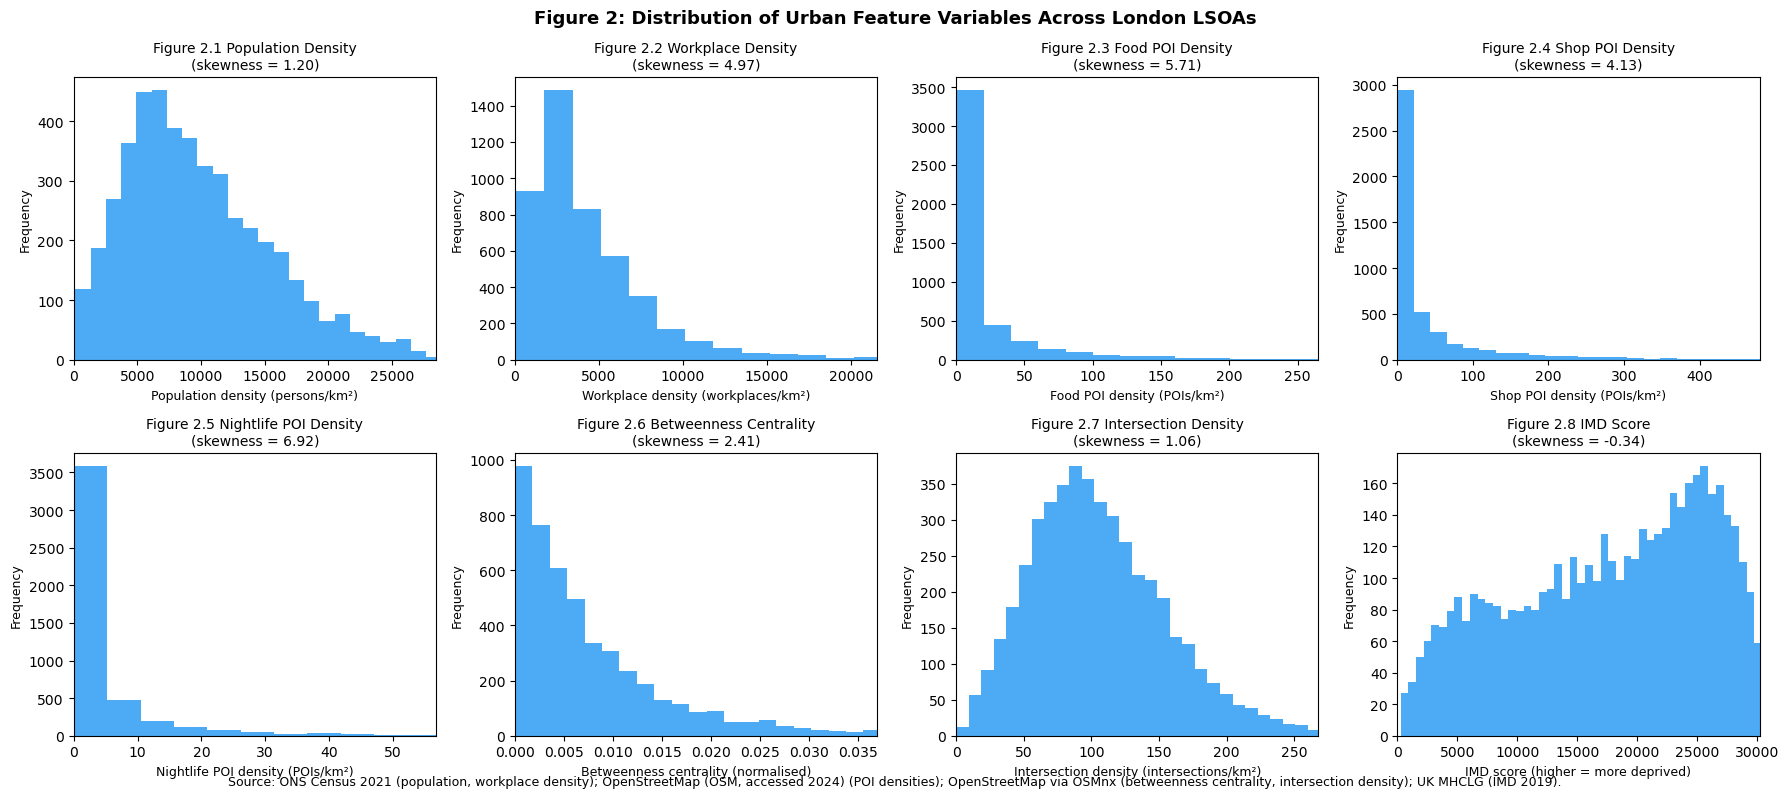


── Figure 2: Skewness Summary ──
  Population Density       : skewness = 1.20
  Workplace Density        : skewness = 4.97
  Food POI Density         : skewness = 5.71
  Shop POI Density         : skewness = 4.13
  Nightlife POI Density    : skewness = 6.92
  Betweenness Centrality   : skewness = 2.41
  Intersection Density     : skewness = 1.06
  IMD Score                : skewness = -0.34


In [129]:
# Figure 2: Distribution of Urban Feature Variables (X variables)
# Examine raw distributions of all 8 predictor variables.
# High skewness values confirm the need for log1p or rank transformation,
# as applied in Data Processing. intersection_density and imd_score
# are approximately normal/uniform and require no transformation.

cols_x = [
    'pop_density',
    'workplace_density',
    'food_poi_density',
    'shop_poi_density',
    'night_poi_density',
    'betweenness',
    'intersection_density',
    'imd_score'
]

# Map each variable to its source dataframe
source_df = {
    'pop_density':          final_dataset,
    'workplace_density':    final_dataset,
    'food_poi_density':     final_dataset,
    'shop_poi_density':     final_dataset,
    'night_poi_density':    final_dataset,
    'betweenness':          final_dataset,
    'intersection_density': final_dataset,
    'imd_score':            imd
}

titles = {
    'pop_density':          'Population Density',
    'workplace_density':    'Workplace Density',
    'food_poi_density':     'Food POI Density',
    'shop_poi_density':     'Shop POI Density',
    'night_poi_density':    'Nightlife POI Density',
    'betweenness':          'Betweenness Centrality',
    'intersection_density': 'Intersection Density',
    'imd_score':            'IMD Score'
}

xlabels = {
    'pop_density':          'Population density (persons/km²)',
    'workplace_density':    'Workplace density (workplaces/km²)',
    'food_poi_density':     'Food POI density (POIs/km²)',
    'shop_poi_density':     'Shop POI density (POIs/km²)',
    'night_poi_density':    'Nightlife POI density (POIs/km²)',
    'betweenness':          'Betweenness centrality (normalised)',
    'intersection_density': 'Intersection density (intersections/km²)',
    'imd_score':            'IMD score (higher = more deprived)'
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(
    "Figure 2: Distribution of Urban Feature Variables Across London LSOAs",
    fontsize=13, fontweight='bold'
)

for i, col in enumerate(cols_x):
    ax   = axes[i // 4, i % 4]
    data = source_df[col][col].dropna()
    skew = data.skew()
    ax.hist(data, bins=50, color='#2196F3', alpha=0.8)
    ax.set_title(
        f"Figure 2.{i+1} {titles[col]}\n(skewness = {skew:.2f})",
        fontsize=10
    )
    ax.set_xlabel(xlabels[col], fontsize=9)
    ax.set_ylabel("Frequency", fontsize=9)
    # Clip x-axis at 99th percentile to suppress extreme outliers
    ax.set_xlim(0, data.quantile(0.99))

plt.tight_layout()
plt.figtext(
    0.5, 0.01,
    "Source: ONS Census 2021 (population, workplace density); "
    "OpenStreetMap (OSM, accessed 2024) (POI densities); "
    "OpenStreetMap via OSMnx (betweenness centrality, intersection density); "
    "UK MHCLG (IMD 2019).",
    ha="center", fontsize=9
)
plt.show()

# Skewness values guide transformation decisions in Data Processing
print("\n── Figure 2: Skewness Summary ──")
for col in cols_x:
    data = source_df[col][col].dropna()
    print(f"  {titles[col]:25s}: skewness = {data.skew():.2f}")

### 4.2 relation

**1.Figure 3.1**
Violence decreases as deprivation decreases (Q1: ≈36; Q5: ≈13), showing a clear relationship between socioeconomic deprivation and violence. Theft also shows an overall downward trend, but the pattern is weaker and more variable. Burglary remains stable across all quintiles (≈5–6), suggesting that it may be driven by different factors.

**2.Figure 3.2**
Theft increases sharply with POI density, reaching around ≈112 (nightlife), ≈97 (food), and ≈82 (shop) at Q5. This suggests that higher activity levels are associated with more theft. Violence increases more gradually. Burglary remains largely unchanged across all POI types.

**3.Figure 3.3**
Workplace density shows a clear positive relationship with theft and a moderate relationship with violence. In contrast, population density shows a weak and inconsistent relationship with all crime types. This suggests that activity-based exposure is more important than residential population.

**4.Figure 3.4**
Intersection density is positively related to theft, increasing to around ≈51 at Q5. Betweenness centrality shows a non-linear pattern, with theft peaking at Q4 and then declining, suggesting a non-linear relationship rather than a continuous increase. Burglary remains stable across both variables.

Across all figures, theft and violence show consistent relationships with urban structural features, while burglary remains stable. This supports the need to model and interpret each crime type separately.

In [134]:
# Figure 3: Relation Analysis
# Examine how each urban feature variable relates to crime rates.
# Each X variable is grouped into quintiles (Q1–Q5) and mean
# crime rates are compared across groups with 95% CI error bars.
# This reveals the direction and strength of X–Y relationships
# prior to modelling.
# Note: crime_rate, final_dataset, imd already loaded in Data Loading cell.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

# Merge datasets
# crime_rate, final_dataset, imd already in memory from Data Loading cell
df_eda = final_dataset.merge(
    crime_rate[['LSOA_code', 'theft_rate', 'burglary_rate', 'violence_rate']],
    on='LSOA_code', how='inner'
).merge(
    imd[['LSOA_code', 'imd_score']],
    on='LSOA_code', how='inner'
)
print(f"Merged rows: {len(df_eda)}")

# Common settings
Q_LABELS   = ['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(Highest)']
CRIME_VARS = ['theft_rate', 'burglary_rate', 'violence_rate']
CRIME_LBLS = ['Theft Rate', 'Burglary Rate', 'Violence Rate']
COLORS     = ['#2196F3', '#FF9800', '#E53935']
BAR_W      = 0.22

def safe_qcut(series, labels):
    """Assign zeros to Q1 if zeros exceed 5%, then split non-zero values into four groups."""
    result = pd.Series([''] * len(series), index=series.index, dtype=object)
    zm = series == 0
    if zm.mean() > 0.05:
        result[zm] = labels[0]
        bins = pd.qcut(series[~zm], q=4, labels=labels[1:], duplicates='drop')
        result[~zm] = bins.astype(str).values
    else:
        result = pd.qcut(series, q=5, labels=labels, duplicates='drop').astype(str)
    return pd.Categorical(result, categories=labels, ordered=True)

def imd_qcut(series, labels):
    """Higher IMD score = more deprived. Q1 = most deprived, Q5 = least deprived."""
    raw = pd.qcut(
        series, q=5,
        labels=['Q5\n(Least Deprived)', 'Q4', 'Q3', 'Q2', 'Q1\n(Most Deprived)'],
        duplicates='drop'
    )
    order = ['Q1\n(Most Deprived)', 'Q2', 'Q3', 'Q4', 'Q5\n(Least Deprived)']
    return pd.Categorical(raw, categories=order, ordered=True)

def plot_grouped_bars(ax, data, x_col, x_unit, q_labels, qcut_fn=None):
    """Plot grouped bars with 95% CI and trend lines."""
    data = data.copy()
    if qcut_fn is not None:
        data['_g'] = qcut_fn(data[x_col], q_labels)
    else:
        data['_g'] = safe_qcut(data[x_col], q_labels)
    grp   = data.groupby('_g', observed=True)[CRIME_VARS]
    means = grp.mean()
    ci95  = grp.sem() * 1.96
    x     = np.arange(len(means))
    for i, (var, lbl, col) in enumerate(zip(CRIME_VARS, CRIME_LBLS, COLORS)):
        off = (i - 1) * BAR_W
        ax.bar(
            x + off, means[var], width=BAR_W,
            yerr=ci95[var], color=col, alpha=0.82,
            capsize=4, error_kw={'linewidth': 0.9},
            label=lbl
        )
        ax.plot(
            x + off, means[var], 'o--', color=col,
            linewidth=1.0, markersize=3.5, zorder=5
        )
    ax.set_xticks(x)
    ax.set_xticklabels(means.index, fontsize=7.5)
    ax.set_xlabel(x_unit, fontsize=7.5)
    ax.set_ylabel('Mean crime rate\n(per 1,000 people)', fontsize=7.5)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='y', labelsize=7.5)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines[['top', 'right']].set_visible(False)

Merged rows: 4653


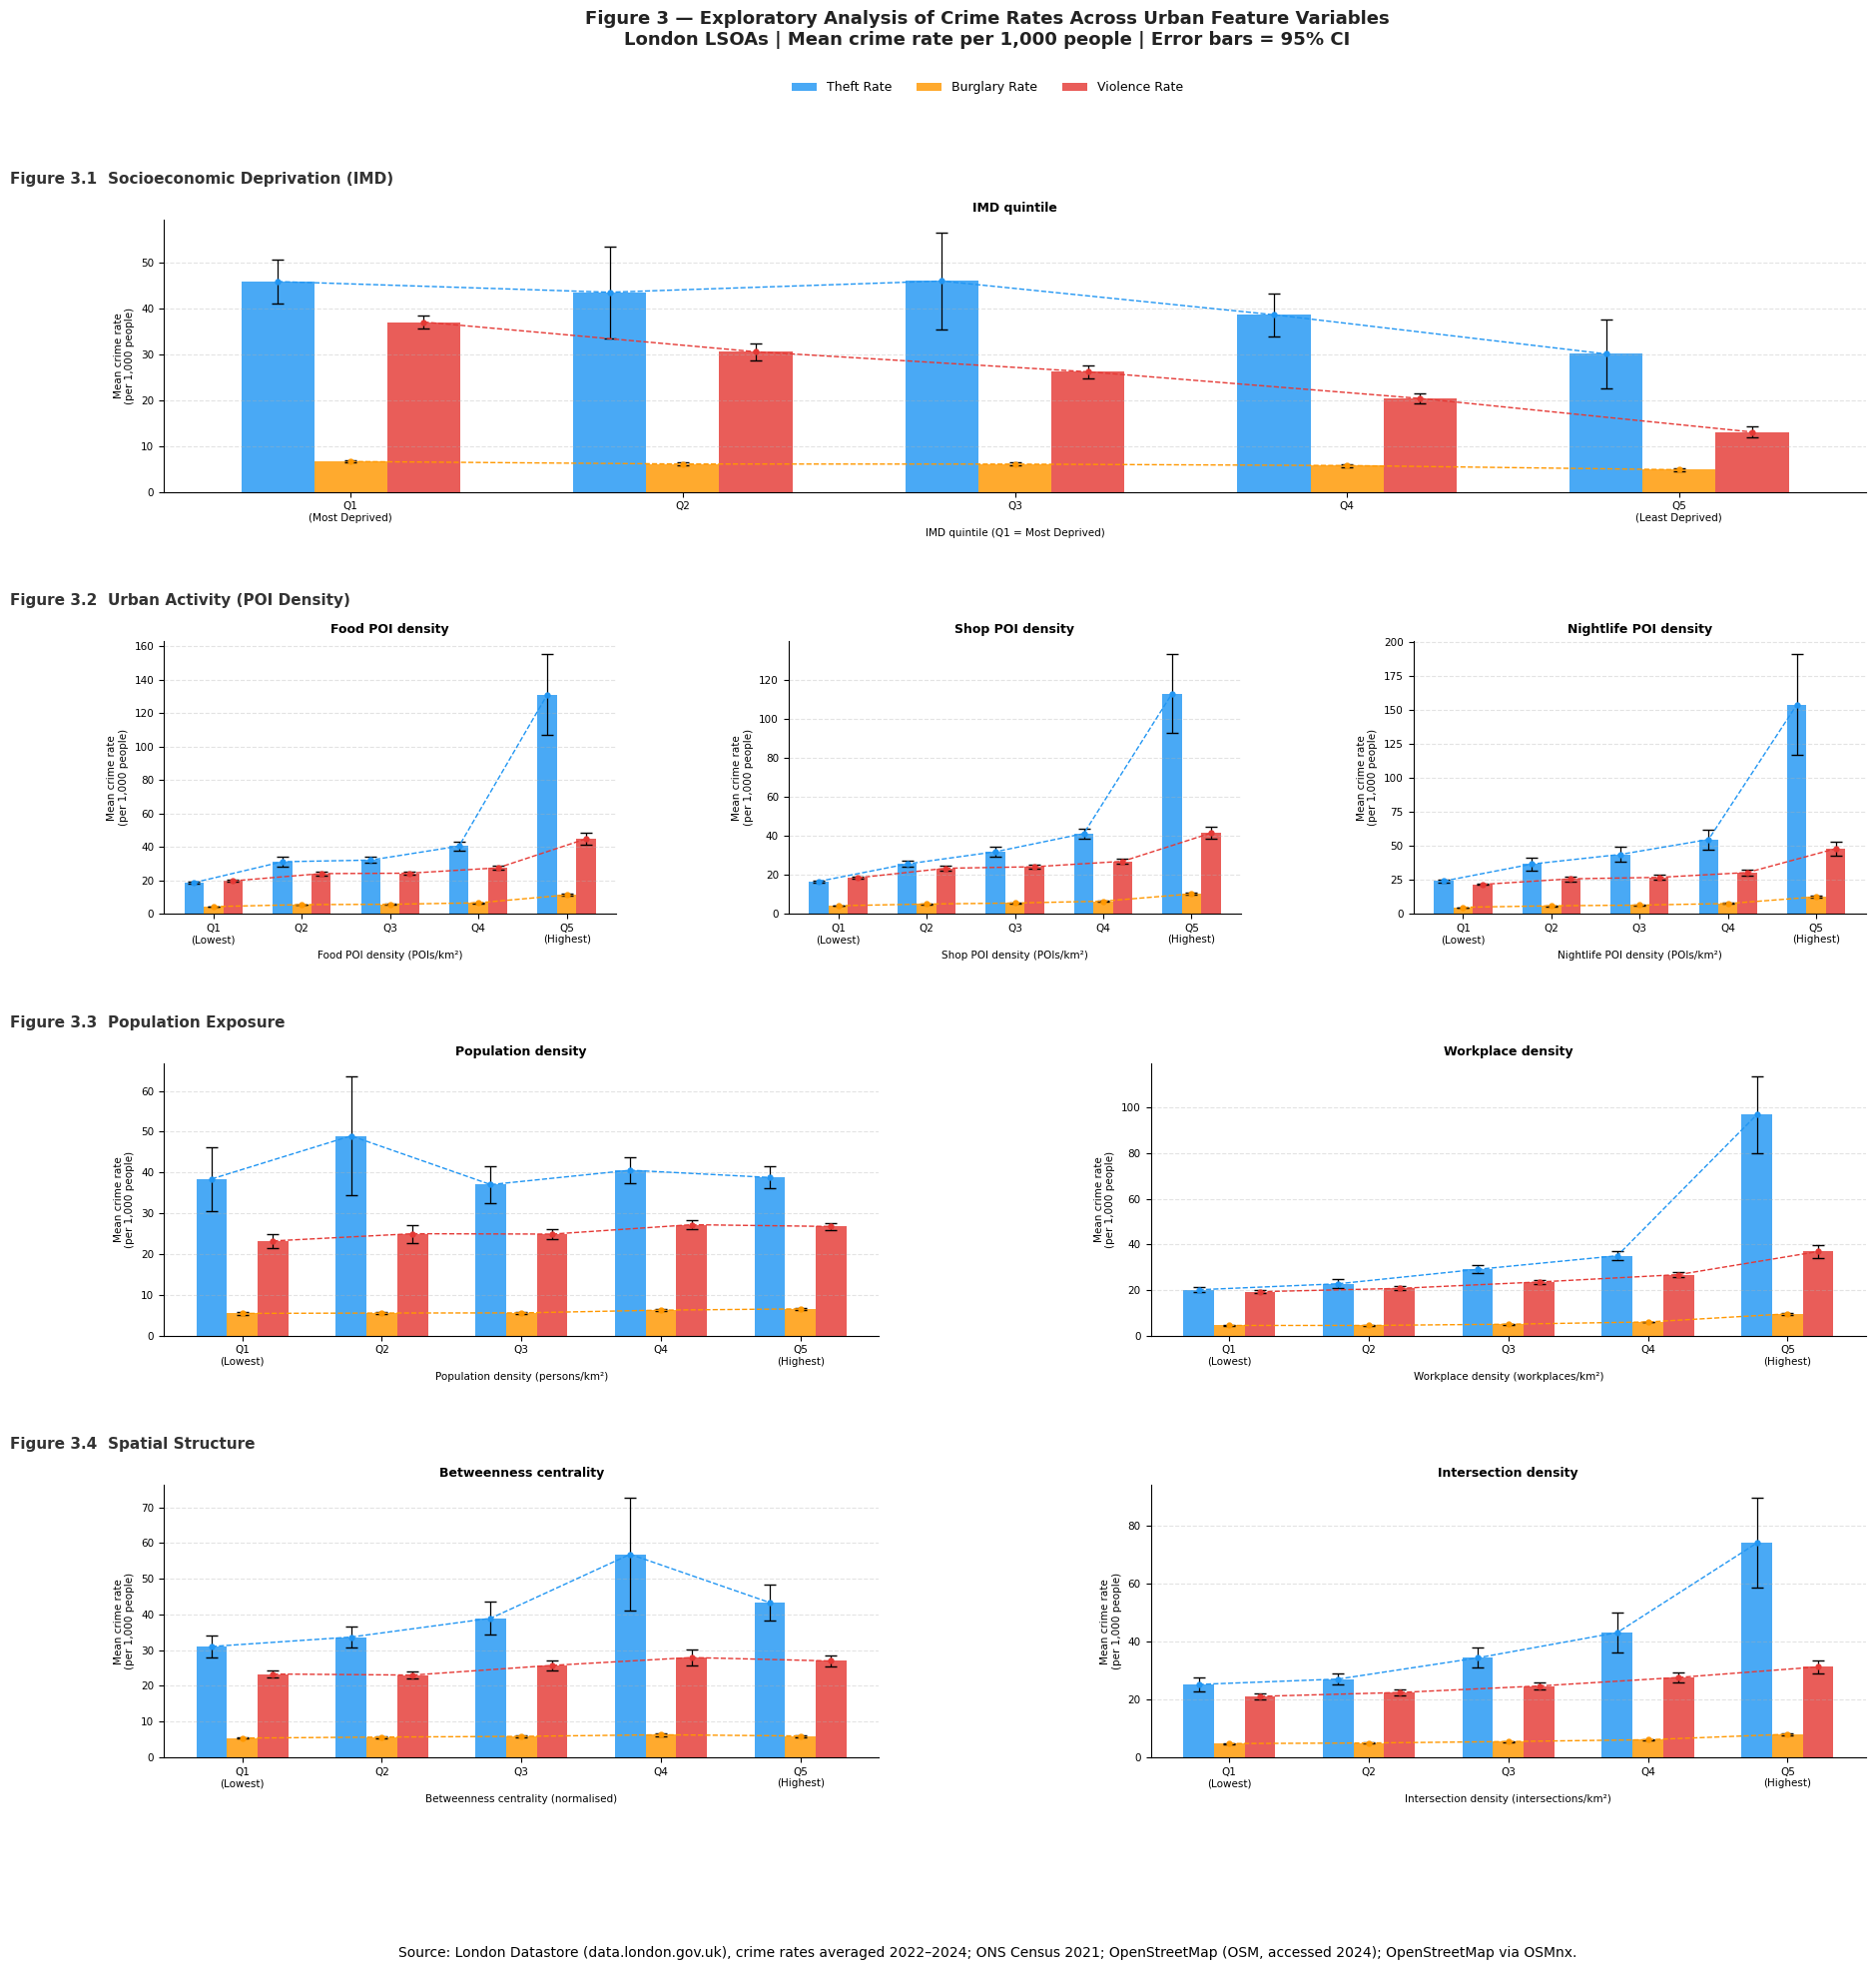

In [135]:
# Define variable groups 
sections = {
    'Figure 3.1  Socioeconomic Deprivation (IMD)': [
        ('imd_score', 'IMD quintile (Q1 = Most Deprived)', 'imd'),
    ],
    'Figure 3.2  Urban Activity (POI Density)': [
        ('food_poi_density',  'Food POI density (POIs/km²)',      'safe'),
        ('shop_poi_density',  'Shop POI density (POIs/km²)',      'safe'),
        ('night_poi_density', 'Nightlife POI density (POIs/km²)', 'safe'),
    ],
    'Figure 3.3  Population Exposure': [
        ('pop_density',       'Population density (persons/km²)',   'safe'),
        ('workplace_density', 'Workplace density (workplaces/km²)', 'safe'),
    ],
    'Figure 3.4  Spatial Structure': [
        ('betweenness',          'Betweenness centrality (normalised)',      'safe'),
        ('intersection_density', 'Intersection density (intersections/km²)', 'safe'),
    ],
}

# Build full panel 
fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor('white')
outer    = GridSpec(4, 1, figure=fig, hspace=0.55)
first_ax = None

for row_idx, (sec_title, var_list) in enumerate(zip(sections.keys(), sections.values())):
    ncols = len(var_list)
    inner = outer[row_idx].subgridspec(1, ncols, wspace=0.38)
    axes  = [fig.add_subplot(inner[0, c]) for c in range(ncols)]
    if first_ax is None:
        first_ax = axes[0]
    fig.text(
        0.055,
        axes[0].get_position().y1 + 0.018,
        sec_title,
        fontsize=11, fontweight='bold',
        color='#333333', transform=fig.transFigure
    )
    for ax, (x_col, x_unit, qtype) in zip(axes, var_list):
        if qtype == 'imd':
            q_labels = ['Q1\n(Most Deprived)', 'Q2', 'Q3', 'Q4', 'Q5\n(Least Deprived)']
            plot_grouped_bars(ax, df_eda, x_col, x_unit, q_labels, qcut_fn=imd_qcut)
        else:
            plot_grouped_bars(ax, df_eda, x_col, x_unit, Q_LABELS)
        var_title = x_unit.split('(')[0].strip()
        ax.set_title(var_title, fontsize=9, fontweight='bold', pad=6)

# Global title and legend
fig.suptitle(
    'Figure 3 — Exploratory Analysis of Crime Rates Across Urban Feature Variables\n'
    'London LSOAs | Mean crime rate per 1,000 people | Error bars = 95% CI',
    fontsize=13, fontweight='bold', y=0.985, color='#222222'
)
handles, labels_leg = first_ax.get_legend_handles_labels()
fig.legend(
    handles, labels_leg,
    loc='upper center', ncol=3, fontsize=9,
    frameon=False, bbox_to_anchor=(0.5, 0.955)
)
plt.figtext(
    0.5, 0.01,
    'Source: London Datastore (data.london.gov.uk), crime rates averaged 2022–2024; '
    'ONS Census 2021; OpenStreetMap (OSM, accessed 2024); OpenStreetMap via OSMnx.',
    ha='center', fontsize=10
)
plt.show()

In [136]:
# Q1 → Q5 change summary 
# Quantifies direction and magnitude of crime rate change
# from lowest to highest quintile for each urban feature variable
print("\n" + "="*65)
print("  Q1 → Q5 Change Summary (Mean crime rate per 1,000 people)")
print("="*65)

for sec_title, var_list in sections.items():
    print(f"\n── {sec_title} ──")
    for x_col, x_unit, qtype in var_list:
        df_tmp = df_eda.copy()
        if qtype == 'imd':
            q_labels = ['Q1\n(Most Deprived)', 'Q2', 'Q3', 'Q4', 'Q5\n(Least Deprived)']
            df_tmp['_g'] = imd_qcut(df_tmp[x_col], q_labels)
        else:
            q_labels = Q_LABELS
            df_tmp['_g'] = safe_qcut(df_tmp[x_col], q_labels)
        means = df_tmp.groupby('_g', observed=True)[CRIME_VARS].mean()
        print(f"\n  {x_unit.split('(')[0].strip()}:")
        for var, lbl in zip(CRIME_VARS, CRIME_LBLS):
            q1  = means[var].iloc[0]
            q5  = means[var].iloc[-1]
            pct = (q5 - q1) / q1 * 100 if q1 != 0 else float('nan')
            direction = '▲' if pct > 0 else '▼'
            print(f"    {lbl:15s}: Q1={q1:6.2f}, Q5={q5:6.2f},  change={pct:+7.1f}%  {direction}")

print("\n" + "="*65)


  Q1 → Q5 Change Summary (Mean crime rate per 1,000 people)

── Figure 3.1  Socioeconomic Deprivation (IMD) ──

  IMD quintile:
    Theft Rate     : Q1= 45.80, Q5= 30.03,  change=  -34.4%  ▼
    Burglary Rate  : Q1=  6.60, Q5=  4.81,  change=  -27.0%  ▼
    Violence Rate  : Q1= 36.98, Q5= 13.03,  change=  -64.8%  ▼

── Figure 3.2  Urban Activity (POI Density) ──

  Food POI density:
    Theft Rate     : Q1= 18.57, Q5=131.08,  change= +605.8%  ▲
    Burglary Rate  : Q1=  4.21, Q5= 11.17,  change= +165.3%  ▲
    Violence Rate  : Q1= 19.59, Q5= 44.78,  change= +128.6%  ▲

  Shop POI density:
    Theft Rate     : Q1= 16.57, Q5=112.97,  change= +581.7%  ▲
    Burglary Rate  : Q1=  4.07, Q5= 10.14,  change= +149.2%  ▲
    Violence Rate  : Q1= 18.41, Q5= 41.36,  change= +124.7%  ▲

  Nightlife POI density:
    Theft Rate     : Q1= 23.99, Q5=153.93,  change= +541.8%  ▲
    Burglary Rate  : Q1=  4.71, Q5= 12.37,  change= +162.6%  ▲
    Violence Rate  : Q1= 21.53, Q5= 47.90,  change= +122.4%  ▲

## 5. Methodology

[[ go back to the top ]](#Table-of-contents)

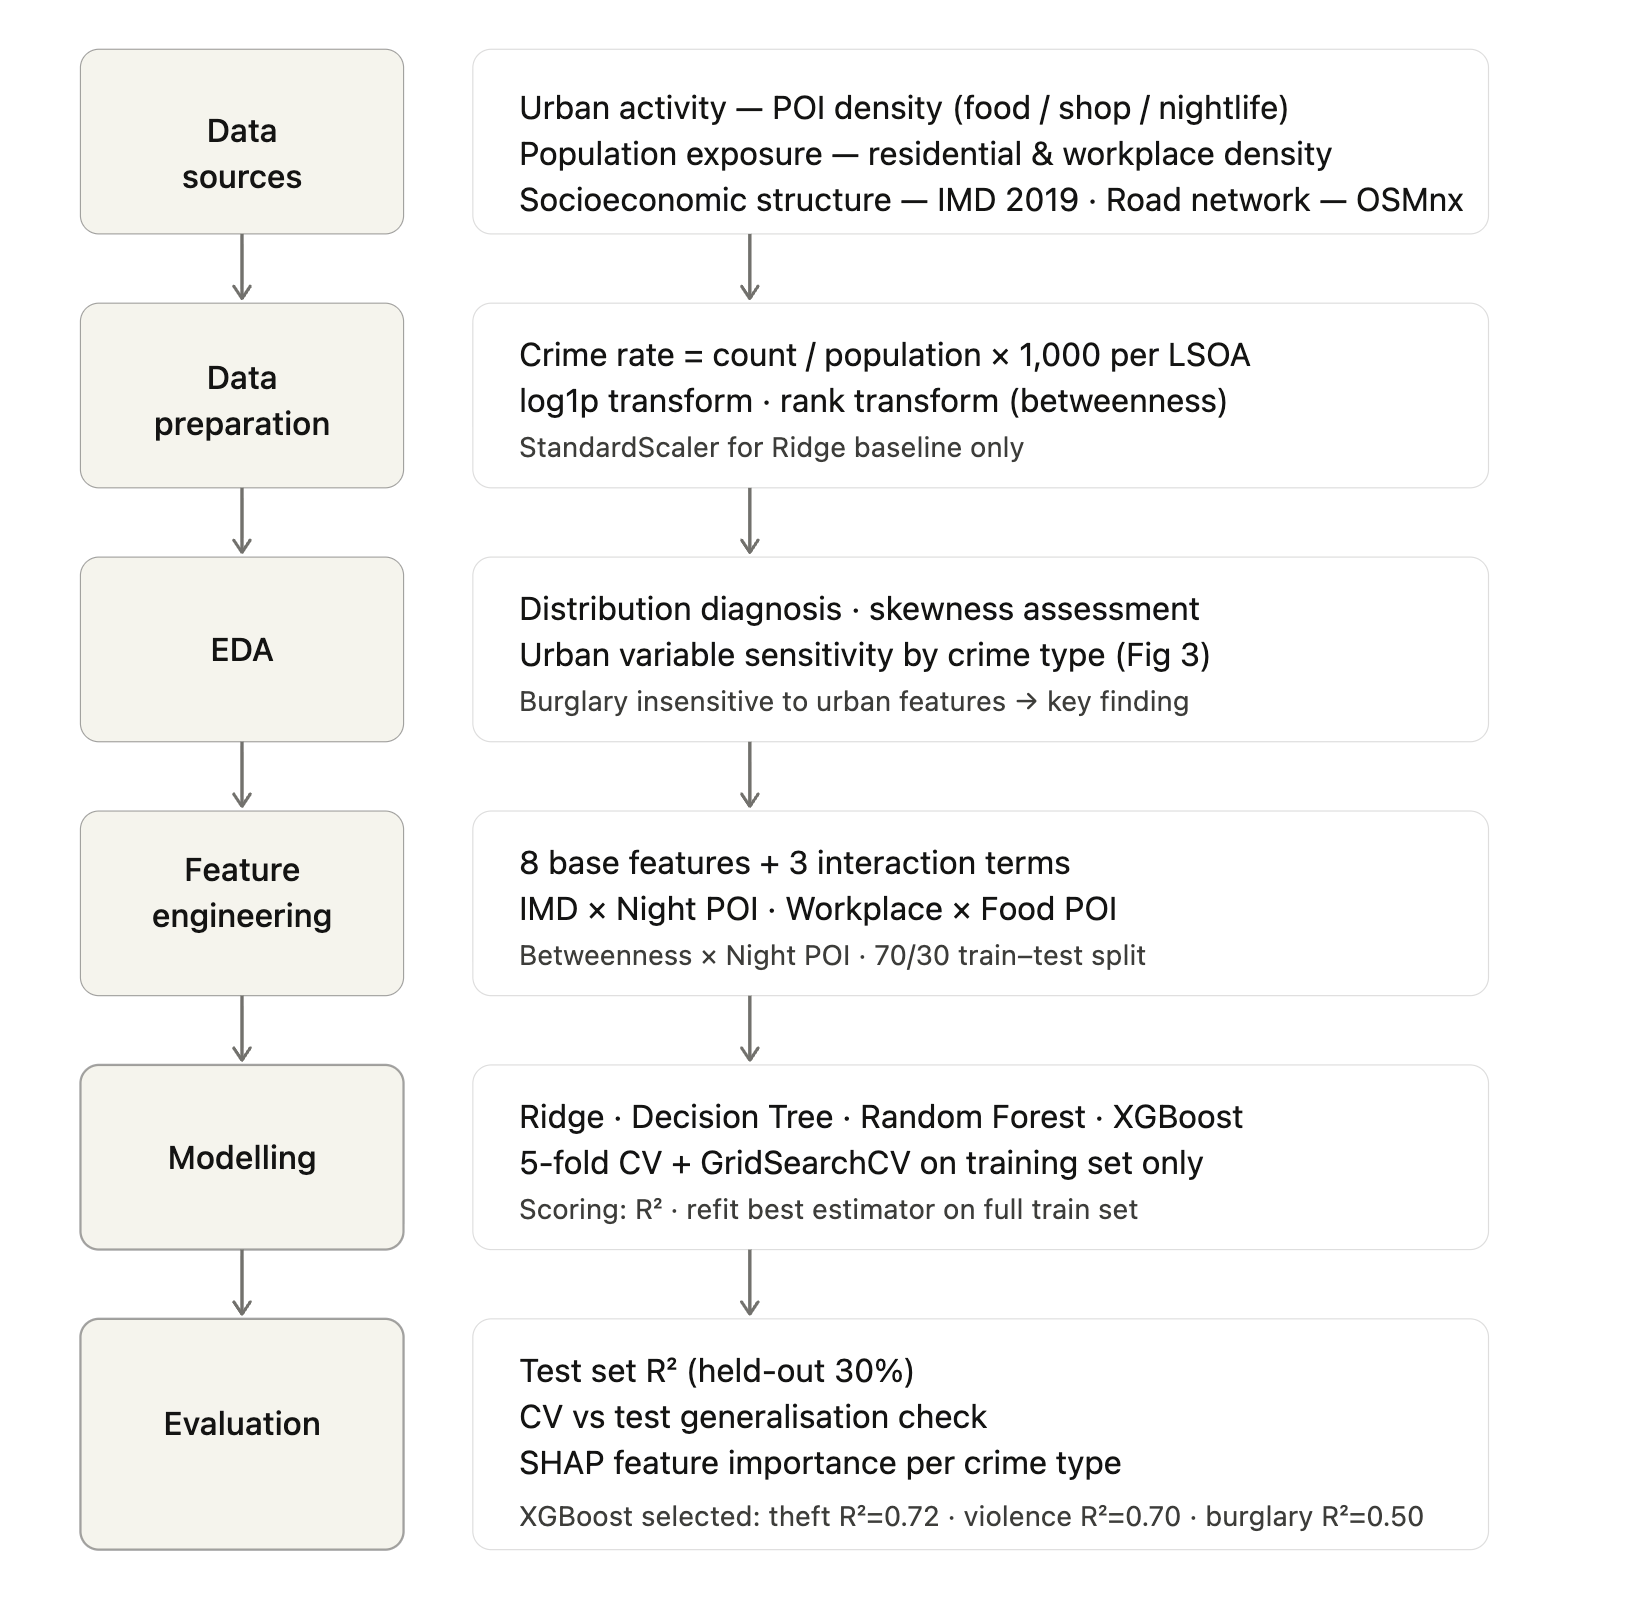

### 5.1 Methodology Selection
Three tree-based models — Decision Tree, Random Forest, and XGBoost — were selected as primary models, with Ridge Regression included as a linear baseline for comparison.

Tree-based models were chosen for three reasons. First, EDA revealed that urban feature variables are predominantly right-skewed and zero-inflated, suggesting non-linear relationships between predictors and crime rates that linear models cannot adequately capture. Second, their ensemble nature effectively manages multicollinearity among correlated urban features. Third, compatibility with SHAP TreeExplainer enables post-hoc interpretability, bridging the gap between predictive performance and spatial policy insights.

In [138]:
# Feature Engineering 
# Construct three interaction terms from standardised base variables
# based on theoretical rationale (Social Disorganization Theory,
# Routine Activity Theory, Crime Pattern Theory).
# All base variables are already log/rank-transformed and standardised
# from the Data Processing cell.
# Data is then split into training (70%) and test (30%) sets.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Step 1: Use processed dataset from previous cell
df = df_final.copy()
print(f"Input shape: {df.shape}")

# Step 2: Define base X and Y columns 
X_BASE = [
    'imd_score',               # socioeconomic deprivation
    'pop_density_log',         # population exposure
    'workplace_density_log',   # population exposure
    'food_poi_density_log',    # urban activity
    'shop_poi_density_log',    # urban activity
    'night_poi_density_log',   # urban activity
    'betweenness_rank',        # road network
    'intersection_density',    # road network
    # 'population' excluded: crime rate = count/population × 1,000
    # including population as X would introduce a denominator effect
]

Y_COLS = ['theft_rate_log', 'burglary_rate_log', 'violence_rate_log']

# Step 3: Feature engineering — interaction terms
# imd_x_night:      deprivation amplified by nightlife exposure
#                   (Social Disorganization Theory)
# workplace_x_food: daytime activity intensity in commercial areas
#                   (Routine Activity Theory)
# btwn_x_night:     network hub exposure during nighttime activity
#                   (Crime Pattern Theory)
print("\n── Step 3: Feature engineering ──")

interactions = {
    'imd_x_night':      ('imd_score',            'night_poi_density_log'),
    'workplace_x_food': ('workplace_density_log', 'food_poi_density_log'),
    'btwn_x_night':     ('betweenness_rank',      'night_poi_density_log'),
}

df_fe = df[['LSOA_code'] + X_BASE + Y_COLS].copy()

for name, (col_a, col_b) in interactions.items():
    df_fe[name] = df_fe[col_a] * df_fe[col_b]
    print(f"  {name:20s} = {col_a} × {col_b}")

X_ALL = X_BASE + list(interactions.keys())
print(f"\n  Base features    : {len(X_BASE)}")
print(f"  Interaction terms: {len(interactions)}")
print(f"  Total X features : {len(X_ALL)}")

# Step 4: Train/Test split 70/30 
# Test set is held out and never used during training or tuning.
# Stratification is not applied as Y is continuous (regression task).
print("\n── Step 4: Train/Test split (70/30, random_state=42) ──")

RANDOM_STATE = 42
X = df_fe[X_ALL]
Y = df_fe[Y_COLS]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=RANDOM_STATE
)

print(f"  Train : {len(X_train):,} rows  (70%)")
print(f"  Test  : {len(X_test):,} rows   (30%)")
print(f"\n  X columns ({len(X_ALL)}): {X_ALL}")
print(f"  Y columns (3)         : {Y_COLS}")
print(f"  Random state          : {RANDOM_STATE}")

# Note 
# X_train, X_test, Y_train, Y_test, df_fe retained in memory
# for subsequent modelling and evaluation cells.

Input shape: (4653, 12)

── Step 3: Feature engineering ──
  imd_x_night          = imd_score × night_poi_density_log
  workplace_x_food     = workplace_density_log × food_poi_density_log
  btwn_x_night         = betweenness_rank × night_poi_density_log

  Base features    : 8
  Interaction terms: 3
  Total X features : 11

── Step 4: Train/Test split (70/30, random_state=42) ──
  Train : 3,257 rows  (70%)
  Test  : 1,396 rows   (30%)

  X columns (11): ['imd_score', 'pop_density_log', 'workplace_density_log', 'food_poi_density_log', 'shop_poi_density_log', 'night_poi_density_log', 'betweenness_rank', 'intersection_density', 'imd_x_night', 'workplace_x_food', 'btwn_x_night']
  Y columns (3)         : ['theft_rate_log', 'burglary_rate_log', 'violence_rate_log']
  Random state          : 42


### 5.2 Hyperparameter Tuning and Cross-Validation

#### 5.2.1 Hyperparameter Tuning

All four models were tuned using GridSearchCV on the training set. The hyperparameter search spaces are summarised below.

| Model | Parameters Searched |
|---|---|
| Ridge | `alpha` ∈ {0.01, 0.1, 1.0, 10.0, 100.0} |
| Decision Tree | `max_depth` ∈ {4, 6, 8, 12}; `min_samples_leaf` ∈ {10, 20, 50} |
| Random Forest | `n_estimators` ∈ {100, 200}; `max_depth` ∈ {4, 6}; `max_features` ∈ {sqrt, 0.3}; `min_samples_leaf` ∈ {20, 50} |
| XGBoost | `n_estimators` ∈ {100, 200}; `max_depth` ∈ {4, 6}; `learning_rate` ∈ {0.05, 0.1}; `subsample` ∈ {0.8, 1.0} |

*Table 1: Hyperparameter search spaces for all four models.*

#### 5.2.2 Cross-Validation Strategy

Model selection followed a 5-fold cross-validation strategy on the 70% training set. The training set was shuffled prior to fold assignment (`random_state=42`) to ensure random distribution across folds. `return_train_score=True` was enabled to monitor overfitting by comparing Train R² against CV R² across all models.

In [99]:
!pip install xgboost

In [143]:
# Modelling: Hyperparameter Tuning + Cross-Validation 
# Hyperparameter tuning via 5-fold cross-validation on training set only.
# Test set is never touched in this cell.
# Four models are tuned per crime type:
# Ridge: linear baseline
# Decision Tree, Random Forest, XGBoost: primary tree-based models
# Best estimator for each model/target combination is saved to memory.

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model    import Ridge
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor
from xgboost                 import XGBRegressor
import joblib
import os

os.makedirs('outputs', exist_ok=True)

# ── Step 1: Use train set from Feature Engineering cell ───────
# X_train, Y_train already in memory — no file loading needed
X_COLS = [
    'imd_score', 'pop_density_log', 'workplace_density_log',
    'food_poi_density_log', 'shop_poi_density_log', 'night_poi_density_log',
    'betweenness_rank', 'intersection_density',
    'imd_x_night', 'workplace_x_food', 'btwn_x_night',
]
Y_COLS = {
    'Y1_theft':    'theft_rate_log',
    'Y2_burglary': 'burglary_rate_log',
    'Y3_violence': 'violence_rate_log',
}

print(f"Train set: {X_train.shape}")
print(f"Features : {X_COLS}\n")

# ── Step 2: CV strategy ───────────────────────────────────────
# 5-fold KFold on training set only
# Shuffle ensures random distribution of spatial clusters across folds
RANDOM_STATE = 42
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Step 3: Model configs + hyperparameter grids ─────────────
# Random Forest: max_depth capped and min_samples_leaf increased
# to address overfitting observed in initial runs (Train R² ~0.92–0.95)
model_configs = {
    'Ridge': {
        'estimator': Ridge(),
        'param_grid': {
            'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
        }
    },
    'Decision Tree': {
        'estimator': DecisionTreeRegressor(random_state=RANDOM_STATE),
        'param_grid': {
            'max_depth':        [4, 6, 8, 12],
            'min_samples_leaf': [10, 20, 50],
        }
    },
    'Random Forest': {
        'estimator': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
        'param_grid': {
            'n_estimators':     [100, 200],
            'max_depth':        [4, 6],        # capped to prevent overfitting
            'max_features':     ['sqrt', 0.3],
            'min_samples_leaf': [20, 50],      # larger leaf nodes reduce variance
        }
    },
    'XGBoost': {
        'estimator': XGBRegressor(
            random_state=RANDOM_STATE, n_jobs=1,
            tree_method='hist', verbosity=0
        ),
       'param_grid': {
        'n_estimators':  [100, 200],
        'max_depth':     [4, 6],
        'learning_rate': [0.05, 0.1],
        'subsample':     [0.8, 1.0],
    }
    },
}

# ── Step 4: Tune each model for each crime type ───────────────
# GridSearchCV refits best model on full X_train after tuning
# return_train_score=True allows overfitting detection (Train R² vs CV R²)
all_cv_results = []
best_estimators = {}  # store best estimator per (tag, model) in memory

for tag, col in Y_COLS.items():

    y_tr = Y_train[col]

    print(f"{'='*60}")
    print(f"  {tag}  ({col})")
    print(f"{'='*60}")

    for name, cfg in model_configs.items():

        grid = GridSearchCV(
            cfg['estimator'],
            cfg['param_grid'],
            cv=cv,
            scoring='r2',
            n_jobs=1,
            refit=True,
            return_train_score=True,
        )
        grid.fit(X_train[X_COLS], y_tr)

        best_idx = grid.best_index_
        cv_mean  = grid.cv_results_['mean_test_score'][best_idx]
        cv_std   = grid.cv_results_['std_test_score'][best_idx]
        train_r2 = grid.cv_results_['mean_train_score'][best_idx]

        print(f"  {name:15s}  CV R²={cv_mean:.4f} ± {cv_std:.4f}  "
              f"Train R²={train_r2:.4f}  Best: {grid.best_params_}")

        all_cv_results.append({
            'Target':      tag,
            'Model':       name,
            'CV_R2_mean':  round(cv_mean,  4),
            'CV_R2_std':   round(cv_std,   4),
            'Train_R2':    round(train_r2, 4),
            'Best_params': str(grid.best_params_),
        })

        # Retain best estimator in memory for test evaluation cell
        best_estimators[(tag, name)] = grid.best_estimator_

    print()

# ── Step 5: CV summary ────────────────────────────────────────
# cv_df retained in memory for test evaluation cell
# Compare CV R² across models per crime type to identify best model
cv_df = pd.DataFrame(all_cv_results)

print("═"*60)
print("  CV SUMMARY (sorted by CV R² per target)")
print("═"*60)
for tag in Y_COLS:
    sub = cv_df[cv_df['Target'] == tag].sort_values('CV_R2_mean', ascending=False)
    print(f"\n  {tag}:")
    print(sub[['Model', 'CV_R2_mean', 'CV_R2_std', 'Train_R2']].to_string(index=False))

# ── Note ─────────────────────────────────────────────────────
# cv_df and best_estimators retained in memory for test evaluation cell.
# Best model per crime type selected based on CV R² in next cell.

Train set: (3257, 11)
Features : ['imd_score', 'pop_density_log', 'workplace_density_log', 'food_poi_density_log', 'shop_poi_density_log', 'night_poi_density_log', 'betweenness_rank', 'intersection_density', 'imd_x_night', 'workplace_x_food', 'btwn_x_night']

  Y1_theft  (theft_rate_log)
  Ridge            CV R²=0.6770 ± 0.0168  Train R²=0.6822  Best: {'alpha': 1.0}
  Decision Tree    CV R²=0.5777 ± 0.0223  Train R²=0.6747  Best: {'max_depth': 6, 'min_samples_leaf': 10}
  Random Forest    CV R²=0.6003 ± 0.0189  Train R²=0.6492  Best: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 100}
  XGBoost          CV R²=0.6995 ± 0.0213  Train R²=0.8269  Best: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}

  Y2_burglary  (burglary_rate_log)
  Ridge            CV R²=0.4837 ± 0.0404  Train R²=0.4921  Best: {'alpha': 1.0}
  Decision Tree    CV R²=0.3707 ± 0.0444  Train R²=0.4937  Best: {'max_depth': 6, 'min_samples_leaf': 10}
  Random

### 5.3 Test Set Evaluation and Generalisation Check

All four models were evaluated on the held-out 30% test set using R², RMSE, and 
MAE, with R² as the primary metric for cross-model and cross-crime-type 
comparison. CV R² was compared against Test R² to assess generalisation. SHAP 
TreeExplainer was applied to the best tree-based model for theft and violence; 
Ridge coefficients are reported for burglary. Results are presented in Section 6.

In [153]:
# ── Test Set Evaluation ───────────────────────────────────────
# Evaluate all four models on the held-out 30% test set.
# Models and CV results are loaded from memory (previous cell).
# Figures are produced in the Results cell.
# Produces:
# - results_df            : test set metrics (R², RMSE, MAE) for all models
# - best_model_per_target : best model per crime type for SHAP/Results cell
# - all_preds             : predictions for all models for Results cell

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Step 1: Use test set and CV results from memory ───────────
# X_test, Y_test from Feature Engineering cell
# cv_df, best_estimators from CV Tuning cell
X_COLS = [
    'imd_score', 'pop_density_log', 'workplace_density_log',
    'food_poi_density_log', 'shop_poi_density_log', 'night_poi_density_log',
    'betweenness_rank', 'intersection_density',
    'imd_x_night', 'workplace_x_food', 'btwn_x_night',
]
Y_COLS = {
    'Y1_theft':    'theft_rate_log',
    'Y2_burglary': 'burglary_rate_log',
    'Y3_violence': 'violence_rate_log',
}
MODELS = ['Ridge', 'Decision Tree', 'Random Forest', 'XGBoost']
CRIME_LABELS = {
    'Y1_theft':    'Theft Rate',
    'Y2_burglary': 'Burglary Rate',
    'Y3_violence': 'Violence Rate',
}

print(f"Test set: {X_test.shape}\n")

# ── Step 2: Evaluation function ───────────────────────────────
def evaluate(name, y_true, y_pred):
    """Return R², RMSE, MAE for a single model prediction."""
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return {
        'Model': name,
        'R2':   round(r2,   4),
        'RMSE': round(rmse, 4),
        'MAE':  round(mae,  4),
    }

# ── Step 3: Evaluate all models on test set ───────────────────
all_results = []
all_preds   = {}

for tag, col in Y_COLS.items():
    y_te = Y_test[col]

    print(f"{'='*60}")
    print(f"  {tag}  ({col})")
    print(f"{'='*60}")

    for name in MODELS:
        model  = best_estimators[(tag, name)]
        y_pred = model.predict(X_test[X_COLS])

        res = evaluate(name, y_te, y_pred)
        res['Target'] = tag
        all_results.append(res)

        print(f"  {res['Model']:15s}  "
              f"R²={res['R2']}  RMSE={res['RMSE']}  MAE={res['MAE']}")

        all_preds[(tag, name)] = {
            'y_true': y_te.values,
            'y_pred': y_pred,
            'r2':     res['R2'],
            'rmse':   res['RMSE'],
            'mae':    res['MAE'],
        }
    print()

# ── Step 4: Test set summary ──────────────────────────────────
results_df = pd.DataFrame(all_results)

print("═"*60)
print("  TEST SET SUMMARY (sorted by R² per target)")
print("═"*60)
for tag in Y_COLS:
    sub = results_df[results_df['Target'] == tag].sort_values('R2', ascending=False)
    print(f"\n  {tag}:")
    print(sub[['Model', 'R2', 'RMSE', 'MAE']].to_string(index=False))

# ── Step 5: Select best model per crime type ──────────────────
# Best model selected based on highest Test R²
# Used in Results and SHAP cells
print("\n── Best model per crime type (by Test R²) ──")
best_model_per_target = {}
for tag in Y_COLS:
    sub       = results_df[results_df['Target'] == tag].sort_values('R2', ascending=False)
    best_name = sub.iloc[0]['Model']
    best_model_per_target[tag] = best_name
    print(f"  {tag}: {best_name} (Test R²={sub.iloc[0]['R2']})")

# ── Step 6: CV vs Test generalisation check (print only) ─────
# Figures produced in Results cell
print("\n" + "═"*60)
print("  CV R² vs TEST R² (generalisation check)")
print("═"*60)
for tag in Y_COLS:
    print(f"\n  {tag}:")
    cv_sub   = cv_df[cv_df['Target'] == tag][['Model', 'CV_R2_mean']].copy()
    test_sub = results_df[results_df['Target'] == tag][['Model', 'R2']].copy()
    cv_sub['Model']   = cv_sub['Model'].str.strip()
    test_sub['Model'] = test_sub['Model'].str.strip()
    merged = cv_sub.merge(test_sub, on='Model', how='inner')
    merged['Gap'] = (merged['R2'] - merged['CV_R2_mean']).round(4)
    merged = merged.sort_values('R2', ascending=False)
    print(merged[['Model', 'CV_R2_mean', 'R2', 'Gap']].to_string(index=False))

# ── Note ─────────────────────────────────────────────────────
# results_df, best_model_per_target, all_preds, best_estimators
# retained in memory for Results and SHAP cells.
print("\n── Test evaluation complete ──")
print("  All figures produced in Results cell.")
print(f"  Best models: {best_model_per_target}")

Test set: (1396, 11)

  Y1_theft  (theft_rate_log)
  Ridge            R²=0.6564  RMSE=0.5933  MAE=0.4633
  Decision Tree    R²=0.5314  RMSE=0.6929  MAE=0.5273
  Random Forest    R²=0.598  RMSE=0.6418  MAE=0.4857
  XGBoost          R²=0.6887  RMSE=0.5648  MAE=0.4354

  Y2_burglary  (burglary_rate_log)
  Ridge            R²=0.4778  RMSE=0.7219  MAE=0.5738
  Decision Tree    R²=0.3281  RMSE=0.8188  MAE=0.6479
  Random Forest    R²=0.3919  RMSE=0.7789  MAE=0.613
  XGBoost          R²=0.4581  RMSE=0.7353  MAE=0.5797

  Y3_violence  (violence_rate_log)
  Ridge            R²=0.6988  RMSE=0.5354  MAE=0.4142
  Decision Tree    R²=0.566  RMSE=0.6427  MAE=0.4851
  Random Forest    R²=0.6206  RMSE=0.6009  MAE=0.4504
  XGBoost          R²=0.707  RMSE=0.5281  MAE=0.4039

════════════════════════════════════════════════════════════
  TEST SET SUMMARY (sorted by R² per target)
════════════════════════════════════════════════════════════

  Y1_theft:
        Model     R2   RMSE    MAE
      XGBoost 0.6

## 6. Results and Discussion

### 6.1 Cross-Validation Model Comparison
Table 2 summarises the 5-fold cross-validation R² across all models and crime types. 

XGBoost achieved the highest CV R² for theft (0.700 ± 0.021) and violence (0.725 ± 0.015), with low fold-to-fold variance indicating stable generalisation. Ridge regression performed best for burglary (0.484 ± 0.040), marginally outperforming XGBoost (0.476) despite XGBoost achieving a higher training R² (0.608), suggesting overfitting without generalisation gain for this crime type. Random Forest ranked second for both theft (0.600) and violence (0.622), while Decision Tree consistently produced the lowest CV R² across all crime types. XGBoost was therefore selected as the best model for theft and violence; Ridge regression was selected for burglary.

Violence was the most predictable target, followed by theft, while burglary showed considerably weaker performance across all models, suggesting that burglary is less structured by the urban features included in this study and may be driven by factors not captured in the current feature set, such as residential characteristics and social cohesion.

| Model | Theft CV R² | Burglary CV R² | Violence CV R² |
|-------|:-----------:|:--------------:|:--------------:|
| Ridge | 0.677 ± 0.017 | **0.484 ± 0.040** | 0.703 ± 0.015 |
| Decision Tree | 0.578 ± 0.022 | 0.371 ± 0.044 | 0.594 ± 0.016 |
| Random Forest | 0.600 ± 0.019 | 0.420 ± 0.032 | 0.622 ± 0.021 |
| **XGBoost** | **0.700 ± 0.021** | 0.476 ± 0.036 | **0.725 ± 0.015** |

*Table 2: 5-fold cross-validation R² (mean ± std) on training set (n=3,261). Bold indicates best performance per target.*

### 6.2 Test Set Evaluation

Table 3 reports final performance on the held-out 30% test set for the best-performing model per crime type.

Test set results are consistent with cross-validation performance, indicating stable generalisation. Violence shows the highest predictive performance (R² = 0.707), followed by theft (0.689), while burglary performs substantially worse (0.478). Urban structural features explain around 70% of the spatial variation in theft and violence rates across London LSOAs, suggesting strong predictive power.

In contrast, burglary shows lower explanatory power (R² = 0.478) and a higher RMSE (0.722) than theft (0.565) and violence (0.528), indicating a weaker relationship with the urban structural features considered in this study.

| Crime Type | Best Model | Test R² | RMSE |
|---|---|---|---|
| Theft | XGBoost | 0.689 | 0.565 |
| Burglary | Ridge | 0.478 | 0.722 |
| Violence | XGBoost | 0.707 | 0.528 |

*Table 3: Test set performance for the best-performing model per crime type.*

Figure 4 shows that predictions for theft and violence cluster closely around the diagonal, indicating good model fit, while burglary shows greater dispersion. Figure 5 further demonstrates that CV R² and Test R² remain closely aligned across all models, with gaps below 0.02, confirming stable generalisation without evidence of overfitting.

Overall, urban structural features best explain violence, followed closely by theft, while they are insufficient to account for the spatial distribution of burglary.

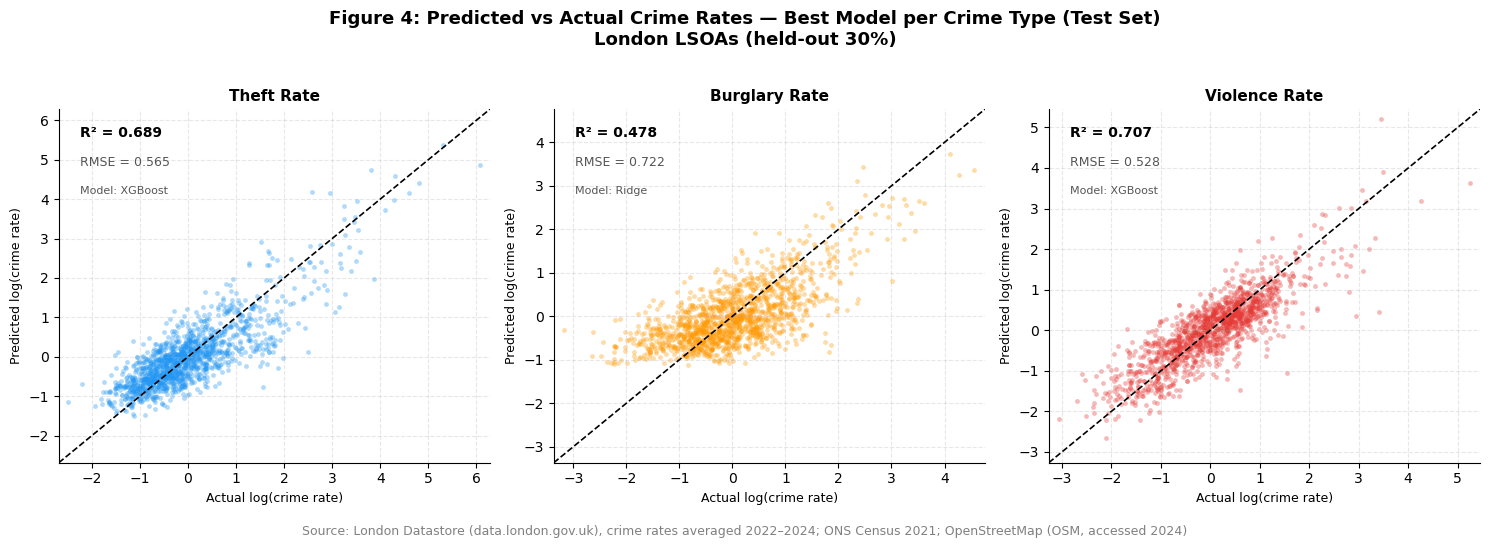

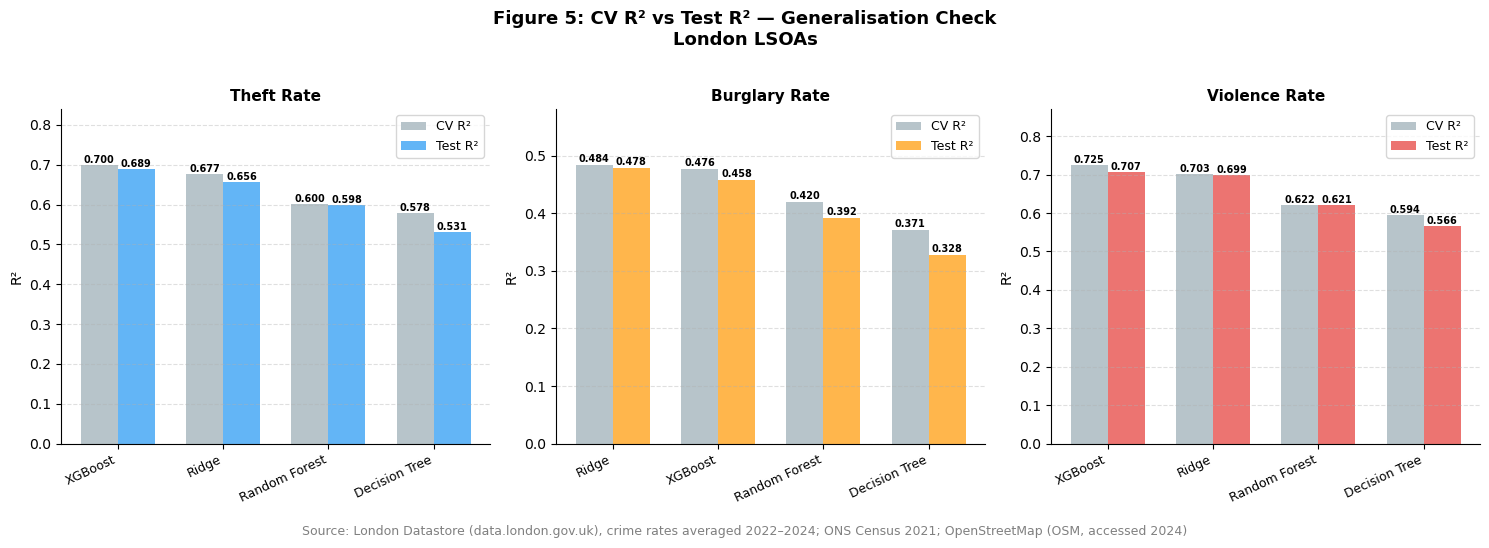


── Results figures complete ──
  Figure 4  — Predicted vs Actual: displayed inline
  Figure 5  — CV vs Test R²:       displayed inline


In [154]:
# ── Results: Figures ──────────────────────────────────────────
# Produces all result figures based on test set evaluation.
# All data loaded from memory (Test Evaluation cell).
# Figure 4: Predicted vs Actual — best model per crime type
# Figure 5: CV R² vs Test R² — generalisation check

import matplotlib.pyplot as plt
import numpy as np

# ── Unified colour scheme ─────────────────────────────────────
CRIME_COLORS = {
    'Y1_theft':    '#2196F3',
    'Y2_burglary': '#FF9800',
    'Y3_violence': '#E53935',
}
MODEL_COLORS = {
    'Ridge':         '#B0BEC5',
    'Decision Tree': '#B0BEC5',
    'Random Forest': '#B0BEC5',
    'XGBoost':       '#1565C0',
}
CRIME_LABELS = {
    'Y1_theft':    'Theft Rate',
    'Y2_burglary': 'Burglary Rate',
    'Y3_violence': 'Violence Rate',
}
Y_COLS = {
    'Y1_theft':    'theft_rate_log',
    'Y2_burglary': 'burglary_rate_log',
    'Y3_violence': 'violence_rate_log',
}

# ── Figure 4: Predicted vs Actual (best model per crime type) ─
# Points close to diagonal indicate accurate predictions
# Colour consistent with crime type colour scheme
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Figure 4: Predicted vs Actual Crime Rates — Best Model per Crime Type (Test Set)\n'
    'London LSOAs (held-out 30%)',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, (tag, col) in zip(axes, Y_COLS.items()):
    best_name = best_model_per_target[tag]
    y_true    = all_preds[(tag, best_name)]['y_true']
    y_pred    = all_preds[(tag, best_name)]['y_pred']
    r2        = all_preds[(tag, best_name)]['r2']
    rmse      = all_preds[(tag, best_name)]['rmse']

    ax.scatter(y_true, y_pred,
               color=CRIME_COLORS[tag], alpha=0.35, s=12, linewidths=0)

    lims = [min(y_true.min(), y_pred.min()) - 0.2,
            max(y_true.max(), y_pred.max()) + 0.2]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect fit')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.text(0.05, 0.92, f'R² = {r2:.3f}',
            transform=ax.transAxes, fontsize=10, fontweight='bold')
    ax.text(0.05, 0.84, f'RMSE = {rmse:.3f}',
            transform=ax.transAxes, fontsize=9, color='#555')
    ax.text(0.05, 0.76, f'Model: {best_name}',
            transform=ax.transAxes, fontsize=8, color='#555')

    ax.set_title(CRIME_LABELS[tag], fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual log(crime rate)', fontsize=9)
    ax.set_ylabel('Predicted log(crime rate)', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(linestyle='--', alpha=0.3)

plt.figtext(
    0.5, -0.03,
    'Source: London Datastore (data.london.gov.uk), crime rates averaged 2022–2024; '
    'ONS Census 2021; OpenStreetMap (OSM, accessed 2024)',
    ha='center', fontsize=9, color='gray'
)
plt.tight_layout()
plt.show()

# ── Figure 5: CV R² vs Test R² — Generalisation Check ────────
# CV R² in grey, Test R² in crime type colour per panel
# Small gap between bars confirms models generalise well
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Figure 5: CV R² vs Test R² — Generalisation Check\n'
    'London LSOAs',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, tag in zip(axes, Y_COLS.keys()):
    cv_sub   = cv_df[cv_df['Target'] == tag][['Model', 'CV_R2_mean']].copy()
    test_sub = results_df[results_df['Target'] == tag][['Model', 'R2']].copy()
    cv_sub['Model']   = cv_sub['Model'].str.strip()
    test_sub['Model'] = test_sub['Model'].str.strip()
    merged = cv_sub.merge(test_sub, on='Model', how='inner')
    merged = merged.sort_values('CV_R2_mean', ascending=False)

    x = np.arange(len(merged))
    w = 0.35

    ax.bar(x - w/2, merged['CV_R2_mean'], width=w,
           color='#B0BEC5', alpha=0.9, label='CV R²')
    ax.bar(x + w/2, merged['R2'], width=w,
           color=CRIME_COLORS[tag], alpha=0.7, label='Test R²')

    for i, row in enumerate(merged.itertuples()):
        ax.text(i - w/2, row.CV_R2_mean + 0.005, f'{row.CV_R2_mean:.3f}',
                ha='center', fontsize=7, fontweight='bold')
        ax.text(i + w/2, row.R2 + 0.005, f'{row.R2:.3f}',
                ha='center', fontsize=7, fontweight='bold')

    ax.set_title(CRIME_LABELS[tag], fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(merged['Model'], rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('R²', fontsize=10)
    ax.set_ylim(0, max(merged['CV_R2_mean'].max(), merged['R2'].max()) * 1.2)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.figtext(
    0.5, -0.03,
    'Source: London Datastore (data.london.gov.uk), crime rates averaged 2022–2024; '
    'ONS Census 2021; OpenStreetMap (OSM, accessed 2024)',
    ha='center', fontsize=9, color='gray'
)
plt.tight_layout()
plt.show()

# ── Note ─────────────────────────────────────────────────────
# SHAP analysis figures (Figure 6+) produced in SHAP cell.
print("\n── Results figures complete ──")
print("  Figure 4  — Predicted vs Actual: displayed inline")
print("  Figure 5  — CV vs Test R²:       displayed inline")

### 6.3 SHAP Feature Importance

**1.Theft Rate (Figure 6a)**

For theft, urban activity variables are the main drivers: Population Density ranks first (mean |SHAP| = 0.268), followed by Food POI Density (0.225), Workplace Density (0.222), and Shop POI Density (0.207). This indicates that daytime activity and commercial density are associated with higher theft risk, consistent with Routine Activity Theory. IMD ranks fifth (0.202) and shows negative SHAP values in more deprived areas, suggesting a weak or inverse association. Road network and interaction terms have limited influence (|SHAP| < 0.06).

**2.Violence Rate (Figure 6b)**

For violence, IMD clearly dominates (mean |SHAP| = 0.552), more than twice Population Density (0.242), indicating that socioeconomic deprivation is the primary spatial driver, consistent with Social Disorganization Theory. Other variables contribute only modestly. This concentrated effect helps explain why violence achieves the highest predictive performance among the three crime types.

**3.Cross-Crime Comparison (Figure 6c)**

The heatmap shows that theft and violence are driven by different mechanisms: theft by urban activity patterns, and violence by deprivation. This difference supports crime-type-specific modelling, as a single feature set does not explain all crime types equally well.

**4.Burglary Rate (Ridge Coefficients)**

Ridge coefficients show weak and mixed associations, consistent with the low R² (0.478). Workplace Density (+0.629) and Population Density (−0.612) act as opposing factors, suggesting that areas with higher daytime activity but lower residential presence may be more exposed to burglary. Overall, the weak pattern indicates that burglary is influenced by factors not captured in the current feature set, such as residential vulnerability and neighbourhood social cohesion.

In [109]:
!pip install shap

SHAP applied to: ['Y1_theft', 'Y3_violence']
Skipped (Ridge — TreeExplainer not applicable): Y2_burglary
Burglary interpretability: Ridge coefficients reported in Figure 6.3

Test set: (1396, 11)

Y1_theft — Top features by mean |SHAP|:
  Population Density              0.2678
  Food POI Density                0.2245
  Workplace Density               0.2224
  Shop POI Density                0.2073
  IMD Score                       0.2017
  Night POI Density               0.0597
  Workplace × Food POI            0.0524
  Betweenness Centrality          0.0202
  Intersection Density            0.0199
  IMD × Night POI                 0.0127
  Betweenness × Night POI         0.0084

Y3_violence — Top features by mean |SHAP|:
  IMD Score                       0.5516
  Population Density              0.2421
  Workplace Density               0.1426
  Food POI Density                0.1331
  Shop POI Density                0.1055
  Betweenness Centrality          0.0476
  IMD × Night POI     

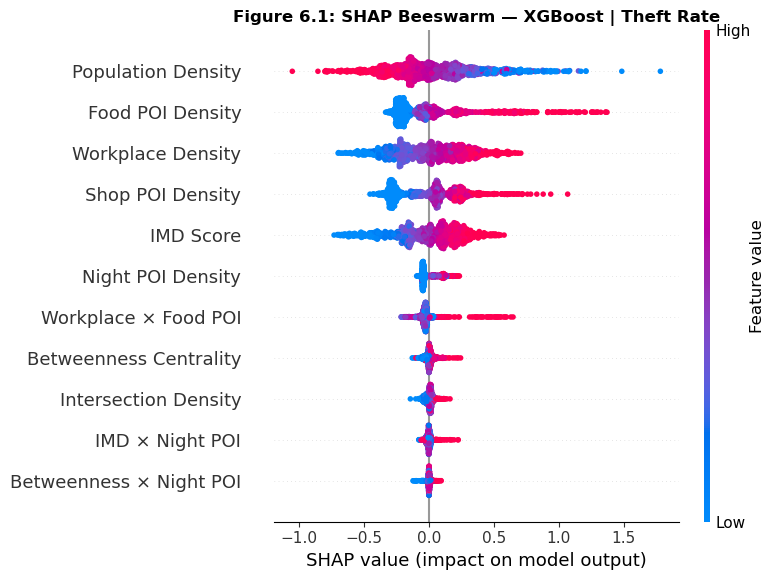

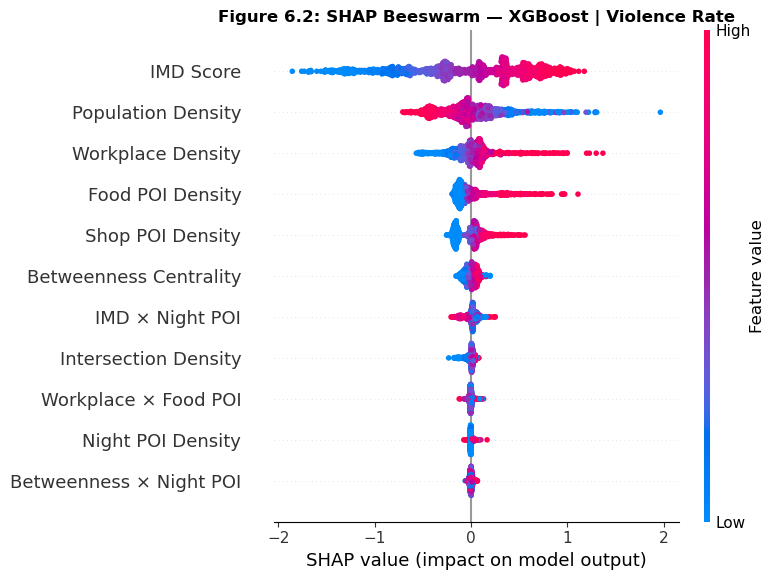


── Burglary (Ridge) — Feature Coefficients ──
Positive = associated with higher burglary rate
Negative = associated with lower burglary rate

  Workplace Density               +0.6291  ▲
  Population Density              -0.6121  ▼
  IMD Score                       +0.2697  ▲
  Shop POI Density                +0.1302  ▲
  Night POI Density               +0.1001  ▲
  Food POI Density                +0.1000  ▲
  Workplace × Food POI            +0.0983  ▲
  Intersection Density            +0.0646  ▲
  Betweenness × Night POI         +0.0451  ▲
  IMD × Night POI                 -0.0101  ▼
  Betweenness Centrality          +0.0001  ▲


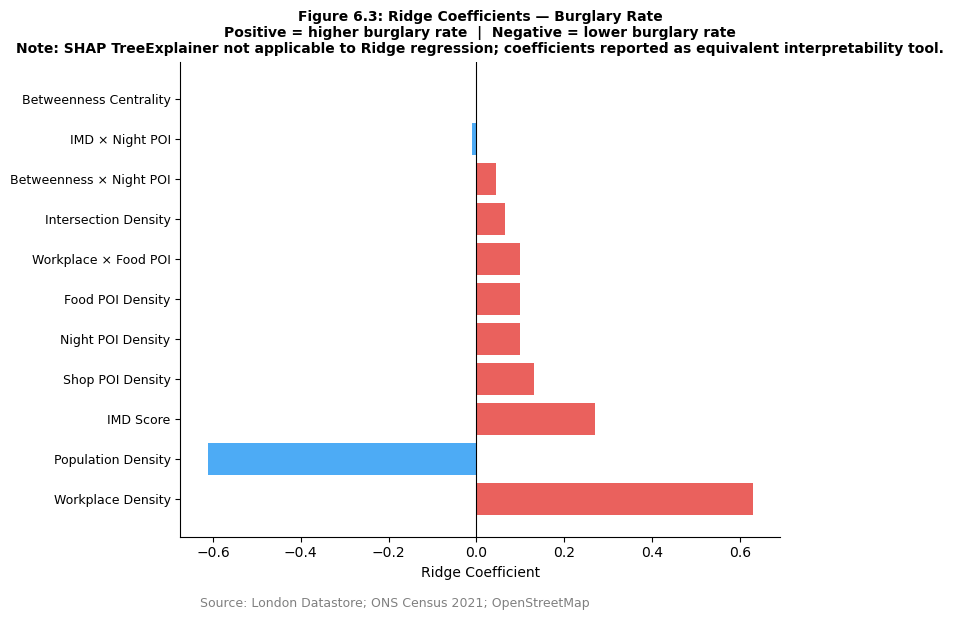

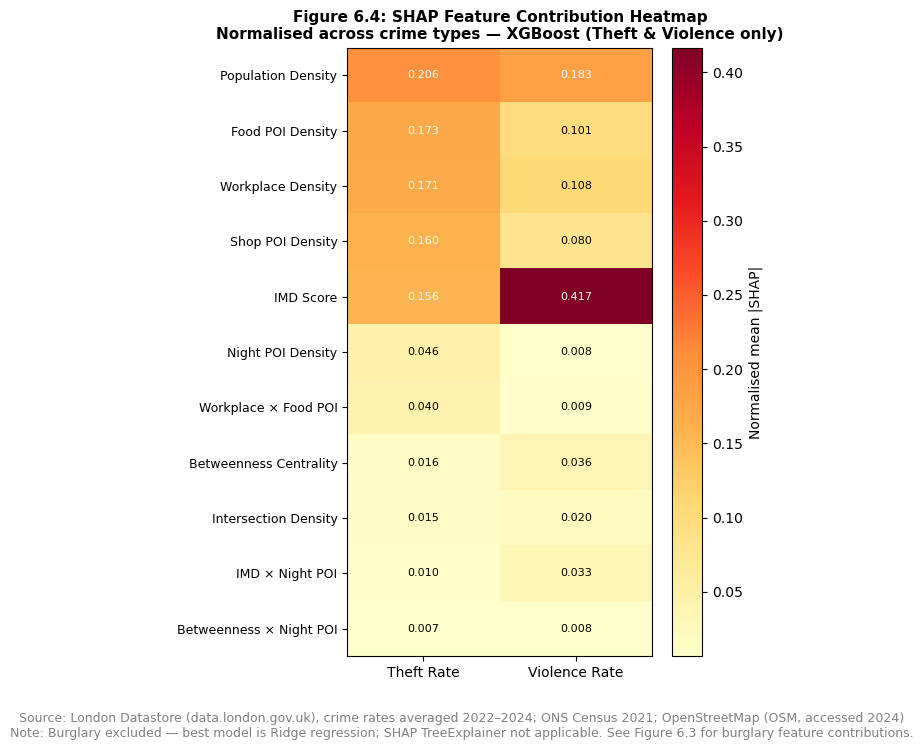


── SHAP analysis complete ──
  Figure 6.1 — Beeswarm Theft:      displayed inline
  Figure 6.2 — Beeswarm Violence:   displayed inline
  Figure 6.3 — Ridge Coefficients:  displayed inline (Burglary)
  Figure 6.4 — Heatmap:             displayed inline (Theft & Violence only)

  Note: Burglary excluded from SHAP — Ridge model used.
        See Figure 6.3 for equivalent linear interpretability.


In [155]:
# ── SHAP Analysis ─────────────────────────────────────────────
# Apply SHAP TreeExplainer to XGBoost models for theft and violence.
# Burglary best model is Ridge — TreeExplainer not applicable;
# Ridge coefficients are reported instead.
# Inputs: X_test, best_estimators from memory (previous cells)
# Produces:
# - Figure 6.1: SHAP Beeswarm — Theft (XGBoost)
# - Figure 6.2: SHAP Beeswarm — Violence (XGBoost)
# - Figure 6.3: Ridge Coefficients — Burglary
# - Figure 6.4: SHAP Feature Contribution Heatmap (Theft & Violence only)

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Feature display names ─────────────────────────────────────
X_COLS = [
    'imd_score', 'pop_density_log', 'workplace_density_log',
    'food_poi_density_log', 'shop_poi_density_log', 'night_poi_density_log',
    'betweenness_rank', 'intersection_density',
    'imd_x_night', 'workplace_x_food', 'btwn_x_night',
]
FEATURE_LABELS = {
    'imd_score':             'IMD Score',
    'pop_density_log':       'Population Density',
    'workplace_density_log': 'Workplace Density',
    'food_poi_density_log':  'Food POI Density',
    'shop_poi_density_log':  'Shop POI Density',
    'night_poi_density_log': 'Night POI Density',
    'betweenness_rank':      'Betweenness Centrality',
    'intersection_density':  'Intersection Density',
    'imd_x_night':           'IMD × Night POI',
    'workplace_x_food':      'Workplace × Food POI',
    'btwn_x_night':          'Betweenness × Night POI',
}
DISPLAY_NAMES = [FEATURE_LABELS[c] for c in X_COLS]

Y_LABELS = {
    'Y1_theft':    'Theft Rate',
    'Y2_burglary': 'Burglary Rate',
    'Y3_violence': 'Violence Rate',
}

# ── SHAP only applied to XGBoost (theft and violence) ─────────
# Note: Burglary is excluded from SHAP analysis because the best-
# performing model for burglary is Ridge regression, for which
# SHAP TreeExplainer is not applicable. Ridge coefficients are
# reported separately in Figure 6.3 as an equivalent interpretability
# tool for the linear model.
SHAP_TARGETS = {
    tag: col for tag, col in {
        'Y1_theft':    'theft_rate_log',
        'Y3_violence': 'violence_rate_log',
    }.items()
}
print(f"SHAP applied to: {list(SHAP_TARGETS.keys())}")
print(f"Skipped (Ridge — TreeExplainer not applicable): Y2_burglary")
print(f"Burglary interpretability: Ridge coefficients reported in Figure 6.3\n")

# ── Prepare test set with display names ───────────────────────
X_test_display = X_test[X_COLS].copy()
X_test_display.columns = DISPLAY_NAMES
print(f"Test set: {X_test_display.shape}")

# ── Compute SHAP values ───────────────────────────────────────
shap_dict    = {}
mean_shap_df = pd.DataFrame(index=DISPLAY_NAMES)

for tag in SHAP_TARGETS:
    model     = best_estimators[(tag, 'XGBoost')]
    explainer = shap.TreeExplainer(model)
    sv        = explainer.shap_values(X_test[X_COLS])
    shap_dict[tag] = sv

    mean_abs = np.abs(sv).mean(axis=0)
    mean_shap_df[Y_LABELS[tag]] = mean_abs

    print(f"\n{tag} — Top features by mean |SHAP|:")
    top = pd.Series(mean_abs, index=DISPLAY_NAMES).sort_values(ascending=False)
    for feat, val in top.items():
        print(f"  {feat:30s}  {val:.4f}")

# ── Figure 6.1: Beeswarm — Theft ─────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_dict['Y1_theft'], X_test_display,
    feature_names=DISPLAY_NAMES,
    show=False, max_display=11
)
plt.title('Figure 6.1: SHAP Beeswarm — XGBoost | Theft Rate',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Figure 6.2: Beeswarm — Violence ──────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_dict['Y3_violence'], X_test_display,
    feature_names=DISPLAY_NAMES,
    show=False, max_display=11
)
plt.title('Figure 6.2: SHAP Beeswarm — XGBoost | Violence Rate',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Figure 6.3: Ridge Coefficients — Burglary ────────────────
# SHAP TreeExplainer is not applicable to Ridge regression.
# Ridge coefficients are reported as an equivalent interpretability
# tool, showing the direction and magnitude of each feature's
# linear association with burglary rate.
burglary_ridge = best_estimators[('Y2_burglary', 'Ridge')]
coef_series = pd.Series(
    burglary_ridge.coef_, index=DISPLAY_NAMES
).sort_values(key=abs, ascending=False)

print("\n── Burglary (Ridge) — Feature Coefficients ──")
print("Positive = associated with higher burglary rate")
print("Negative = associated with lower burglary rate\n")
for feat, val in coef_series.items():
    direction = '▲' if val > 0 else '▼'
    print(f"  {feat:30s}  {val:+.4f}  {direction}")

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E53935' if v > 0 else '#2196F3' for v in coef_series.values]
ax.barh(range(len(coef_series)), coef_series.values, color=colors, alpha=0.8)
ax.set_yticks(range(len(coef_series)))
ax.set_yticklabels(coef_series.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Ridge Coefficient', fontsize=10)
ax.set_title(
    'Figure 6.3: Ridge Coefficients — Burglary Rate\n'
    'Positive = higher burglary rate  |  Negative = lower burglary rate\n'
    'Note: SHAP TreeExplainer not applicable to Ridge regression; '
    'coefficients reported as equivalent interpretability tool.',
    fontsize=10, fontweight='bold'
)
ax.spines[['top', 'right']].set_visible(False)
plt.figtext(
    0.5, -0.02,
    'Source: London Datastore; ONS Census 2021; OpenStreetMap',
    ha='center', fontsize=9, color='gray'
)
plt.tight_layout()
plt.show()

# ── Figure 6.4: Cross-crime heatmap ──────────────────────────
# Normalised SHAP contributions for Theft and Violence only.
# Note: Burglary is excluded as SHAP values are not available for
# Ridge regression. For burglary feature contributions, see
# Figure 6.3 (Ridge coefficients).
mean_shap_norm = mean_shap_df.div(mean_shap_df.sum(axis=0), axis=1)
mean_shap_norm = mean_shap_norm.sort_values('Theft Rate', ascending=False)

fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(mean_shap_norm.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(2))
ax.set_xticklabels(['Theft Rate', 'Violence Rate'], fontsize=10)
ax.set_yticks(range(len(mean_shap_norm)))
ax.set_yticklabels(mean_shap_norm.index, fontsize=9)

for i in range(len(mean_shap_norm)):
    for j in range(2):
        val = mean_shap_norm.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=8, color='black' if val < 0.15 else 'white')

plt.colorbar(im, ax=ax, label='Normalised mean |SHAP|')
ax.set_title(
    'Figure 6.4: SHAP Feature Contribution Heatmap\n'
    'Normalised across crime types — XGBoost (Theft & Violence only)',
    fontsize=11, fontweight='bold'
)
plt.figtext(
    0.5, -0.06,
    'Source: London Datastore (data.london.gov.uk), crime rates averaged 2022–2024; '
    'ONS Census 2021; OpenStreetMap (OSM, accessed 2024)\n'
    'Note: Burglary excluded — best model is Ridge regression; '
    'SHAP TreeExplainer not applicable. See Figure 6.3 for burglary feature contributions.',
    ha='center', fontsize=9, color='gray'
)
plt.tight_layout()
plt.show()

# ── Note ─────────────────────────────────────────────────────
print("\n── SHAP analysis complete ──")
print("  Figure 6.1 — Beeswarm Theft:      displayed inline")
print("  Figure 6.2 — Beeswarm Violence:   displayed inline")
print("  Figure 6.3 — Ridge Coefficients:  displayed inline (Burglary)")
print("  Figure 6.4 — Heatmap:             displayed inline (Theft & Violence only)")
print("\n  Note: Burglary excluded from SHAP — Ridge model used.")
print("        See Figure 6.3 for equivalent linear interpretability.")

## 7. Discussion

### 7.1 Implications of Model Performance

Results confirm that urban structural features explain theft and violence well (Test R² ≈ 0.69–0.71), but are insufficient to account for burglary (Test R² = 0.478). The superior performance of XGBoost for theft and violence suggests non-linear threshold effects between urban activity and crime risk that linear models cannot capture. For burglary, Ridge regression's marginal advantage over XGBoost, combined with consistently low R² across all models, points to a fundamentally different generative mechanism — one driven by factors outside the current feature set, such as residential vulnerability and neighbourhood social cohesion.

#### 7.2 Limitations

- **Data quality.** Crime data are based on police records and may be subject to systematic under-reporting, particularly for lower-severity offences, introducing noise into the target variables.

- **Feature scope.** The analysis is limited to urban structural variables and does not include factors more directly related to burglary, such as household security, target attractiveness, and neighbourhood social cohesion, which likely explains its lower predictive performance.

- **Spatial aggregation.** All variables are aggregated at the LSOA level, which may mask within-area heterogeneity and introduce spatial aggregation effects.

- **Model interpretation.** SHAP results reflect statistical associations rather than causal relationships and should therefore be interpreted with caution.

## 8. Conclusion

[[ go back to the top ]](#Table-of-contents)

This study addressed which crime type is most representative of urban crime across London LSOAs.

The results provide a clear answer. Violence is the most explainable crime type (XGBoost Test R² = 0.707), followed closely by theft (R² = 0.689), indicating that urban form, road network structure, population exposure, and socioeconomic context shape their spatial distributions. By contrast, burglary shows the weakest performance across all models (Test R² = 0.478), with Ridge regression outperforming tree-based models, suggesting a more linear and less spatially structured pattern. This points to the importance of factors beyond urban form—such as target hardening, household security, and social cohesion—in shaping burglary risk.

SHAP analysis further shows that theft and violence operate through distinct mechanisms: violence is primarily driven by socioeconomic deprivation (IMD accounting for 41.7% of normalised SHAP contribution), while theft is influenced by commercial activity and population exposure. The concentrated effect of IMD in the violence model helps explain its higher predictive performance. These findings suggest that different policy levers are needed for different crime types—deprivation reduction for violence, and activity management for theft.

## 9. References

[[ go back to the top ]](#Table-of-contents)

Bernasco, W. and Nieuwbeerta, P. (2005) ‘How do residential burglars select target areas? A new approach to the analysis of criminal location choice’, *British Journal of Criminology*, 45(3), pp. 296–315.

Brantingham, P.J. and Brantingham, P.L. (1993) ‘Environment, routine, and situation: Toward a pattern theory of crime’, *Advances in Criminological Theory*, 5, pp. 259–294.

Cohen, L.E. and Felson, M. (1979) ‘Social change and crime rate trends: A routine activity approach’, *American Sociological Review*, 44(4), pp. 588–608.

Lundberg, S.M. and Lee, S.I. (2017) ‘A unified approach to interpreting model predictions’, *Advances in Neural Information Processing Systems*, 30, pp. 4765–4774.

Mayor of London (2025) *Police and Crime Plan 2025–2029*. London: Mayor’s Office for Policing and Crime (MOPAC). Available at: https://www.london.gov.uk/programmes-strategies/mayors-office-policing-and-crime-mopac/mayors-police-and-crime-plan-2025-2029 (Accessed: 30 April 2026).

Sampson, R.J., Raudenbush, S.W. and Earls, F. (1997) ‘Neighborhoods and violent crime: A multilevel study of collective efficacy’, *Science*, 277(5328), pp. 918–924.

Weisburd, D., Groff, E.R. and Yang, S.M. (2012) *The criminology of place: Street segments and our understanding of the crime problem*. Oxford: Oxford University Press.